# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
import os

search_dirs = [
    os.path.expanduser("~/Downloads"),
    os.path.expanduser("~/Desktop"),
    os.path.expanduser("~"),
    "/tmp",
]

print("Searching for SUSY files...")
for d in search_dirs:
    for root, dirs, files in os.walk(d):
        for f in files:
            if "SUSY" in f or "susy" in f.lower():
                full = os.path.join(root, f)
                size = os.path.getsize(full)
                print(f"  Found: {full}  ({size/1e6:.1f} MB)")

Searching for SUSY files...
  Found: /home/poojanadgir/SUSY.csv.gz  (922.4 MB)


In [3]:
import shutil, gzip, os

shutil.copy("/home/poojanadgir/SUSY.csv.gz", "SUSY.csv.gz")
print("Copied!")

# Extract 500k rows
with gzip.open("SUSY.csv.gz", "rt") as f_in, open("SUSY-small.csv", "w") as f_out:
    for i, line in enumerate(f_in):
        if i >= 500_000:
            break
        f_out.write(line)
print("SUSY-small.csv ready!")

Copied!
SUSY-small.csv ready!


In [4]:
import pandas as pd
VarNames = ["signal","l_1_pT","l_1_eta","l_1_phi","l_2_pT","l_2_eta",
            "l_2_phi","MET","MET_phi","MET_rel","axial_MET","M_R",
            "M_TR_2","R","MT2","S_R","M_Delta_R","dPhi_r_b","cos_theta_r1"]
df = pd.read_csv("SUSY-small.csv", names=VarNames, dtype="float64")
print(f"Rows: {len(df):,} | Signal: {(df.signal==1).sum():,} | Bkg: {(df.signal==0).sum():,}")
df.head()

Rows: 500,000 | Signal: 229,245 | Bkg: 270,755


,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

VarNames = [
    "signal",
    "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi",
    "MET_rel", "axial_MET", "M_R", "M_TR_2", "R",
    "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"
]

RawNames = ["l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi"]

FeatureNames = list(set(VarNames[1:]).difference(RawNames))

df     = pd.read_csv("SUSY-small.csv", dtype="float64", names=VarNames)
df_sig = df[df.signal == 1.0]
df_bkg = df[df.signal == 0.0]

print(f"Loaded {len(df):,} rows | Signal: {len(df_sig):,} | Background: {len(df_bkg):,}")

Loaded 500,000 rows | Signal: 229,245 | Background: 270,755


In [4]:
ls -lh

total 388K
-rwxrwxrwx 1 poojanadgir poojanadgir 387K Apr  4 01:13 Lab.7.ipynb*
-rwxrwxrwx 1 poojanadgir poojanadgir    0 Apr  4 01:13 SUSY-small.csv*


The data is provided as a comma separated file.

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

head: cannot open 'SUSY.csv' for reading: No such file or directory


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 388K
-rwxrwxrwx 1 poojanadgir poojanadgir 387K Apr  4 01:13 Lab.7.ipynb
-rwxrwxrwx 1 poojanadgir poojanadgir    0 Apr  4 01:13 SUSY-small.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

wc: SUSY.csv: No such file or directory


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

head: cannot open 'SUSY.csv' for reading: No such file or directory


In [9]:
ls -lh

total 388K
-rwxrwxrwx 1 poojanadgir poojanadgir 387K Apr  4 01:13 Lab.7.ipynb*
-rwxrwxrwx 1 poojanadgir poojanadgir    0 Apr  4 01:19 SUSY-small.csv*


In [10]:
! wc -l SUSY-small.csv

0 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Define the column names as specified in the lab
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", 
          "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# Load the smaller dataset you created (500,000 rows)
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

# Show the first few rows to make sure it worked
df.head()


,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1


Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['S_R',
 'M_R',
 'cos_theta_r1',
 'M_Delta_R',
 'axial_MET',
 'MT2',
 'R',
 'MET_rel',
 'M_TR_2',
 'dPhi_r_b']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [5]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

FileNotFoundError: [Errno 2] No such file or directory: 'SUSY.csv'

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

/usr/lib/python3/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


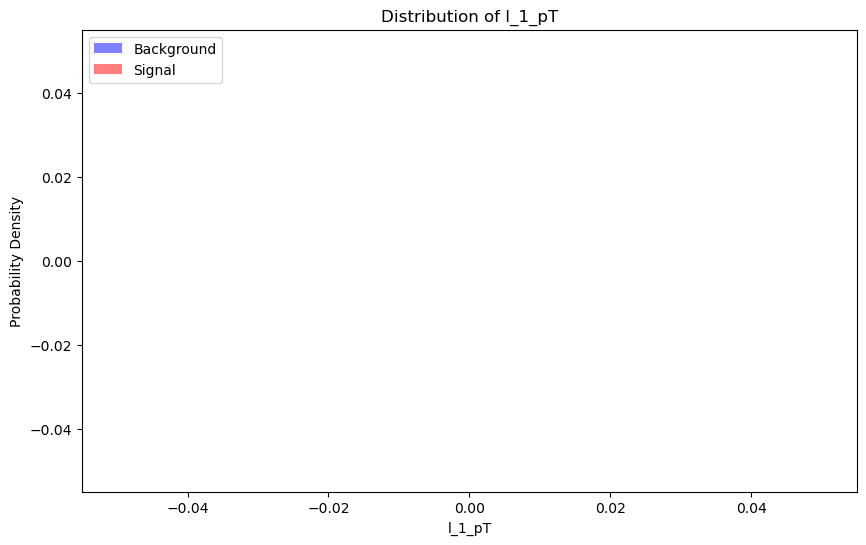

In [5]:
# Choose a variable to plot
target_var = 'l_1_pT'

plt.figure(figsize=(10,6))

# Plot Background in Blue, Signal in Red
plt.hist(df_bkg[target_var], bins=50, range=(0,5), alpha=0.5, label='Background', color='blue', density=True)
plt.hist(df_sig[target_var], bins=50, range=(0,5), alpha=0.5, label='Signal', color='red', density=True)

plt.title(f'Distribution of {target_var}')
plt.xlabel(target_var)
plt.ylabel('Probability Density')
plt.legend()
plt.show()


Generating plot for: l_1_pT


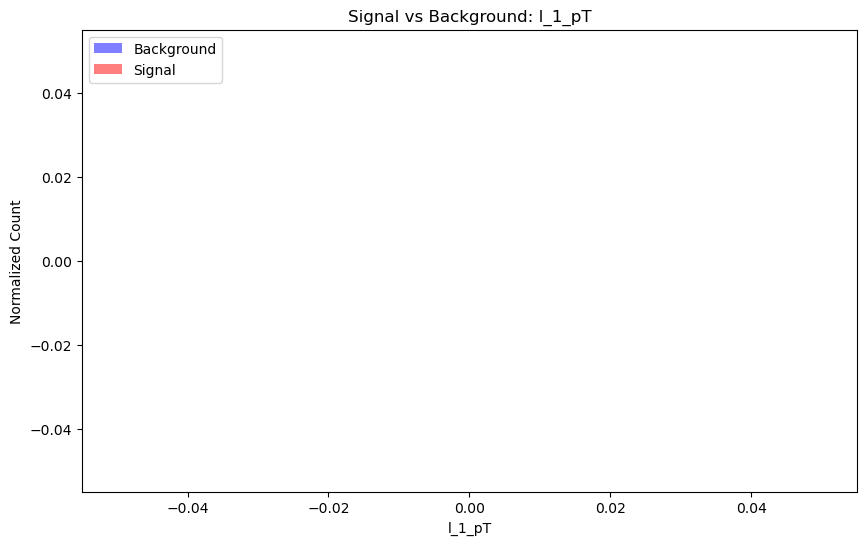

Generating plot for: l_1_eta


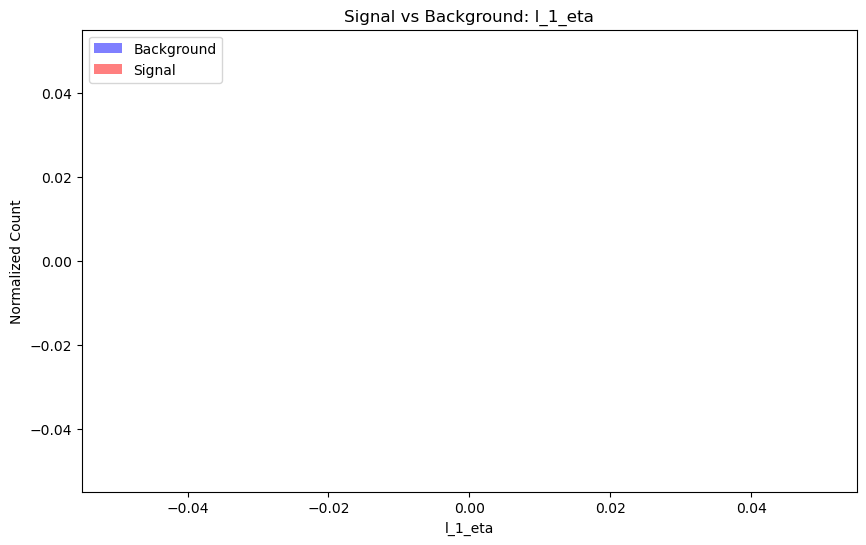

Generating plot for: l_1_phi


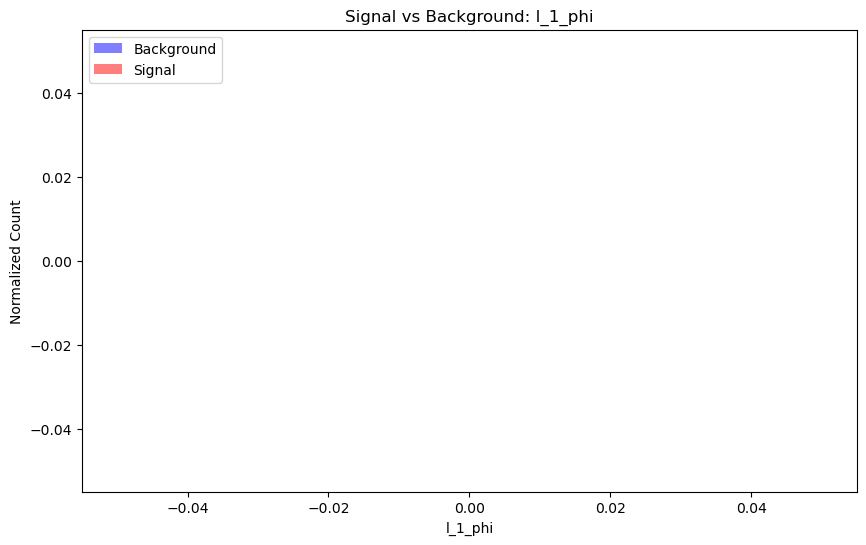

Generating plot for: l_2_pT


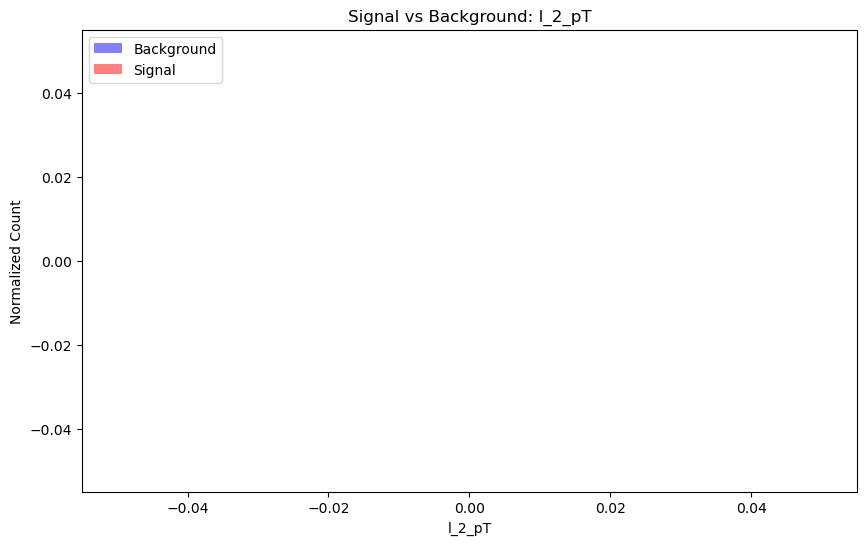

Generating plot for: l_2_eta


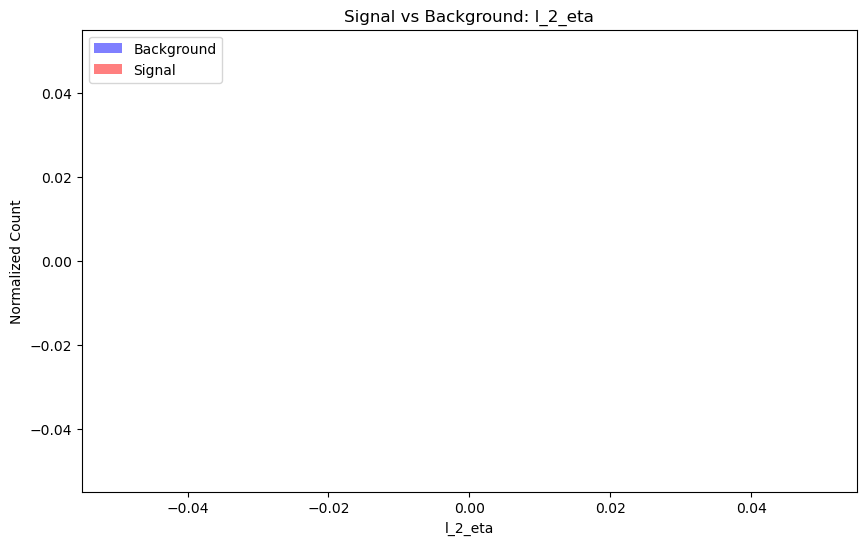

Generating plot for: l_2_phi


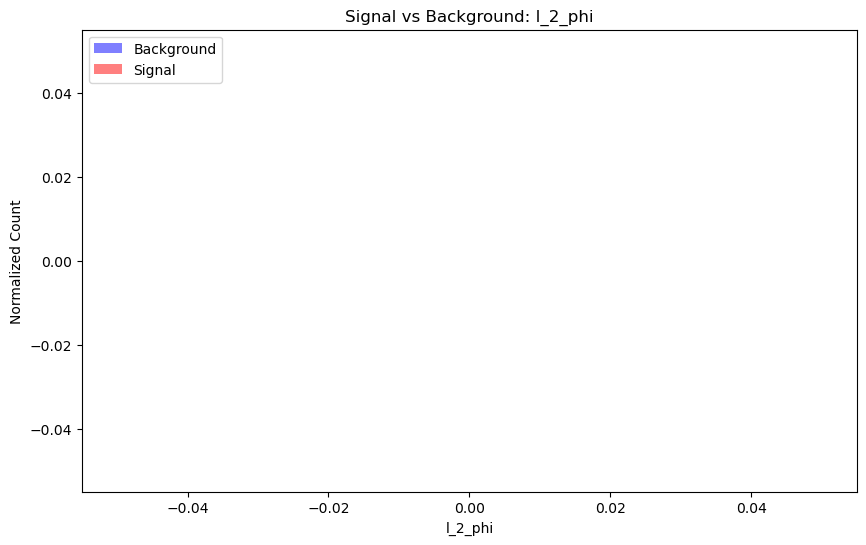

Generating plot for: MET


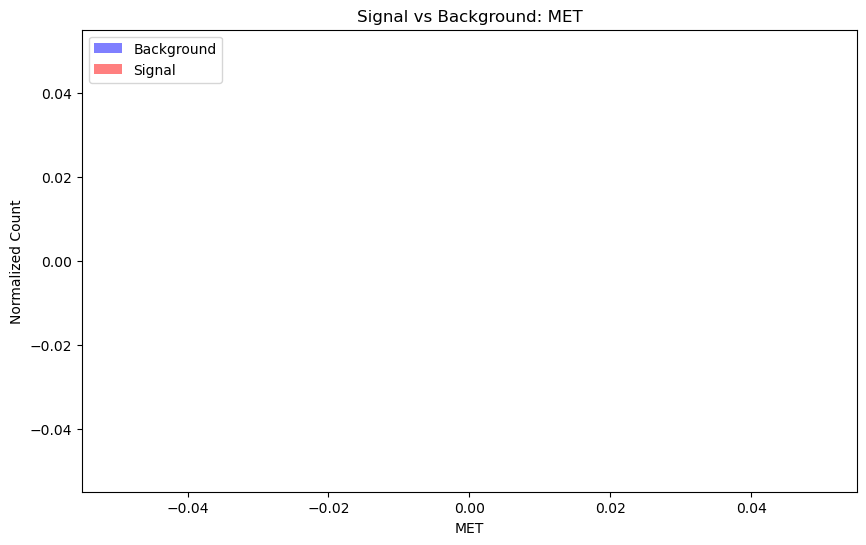

Generating plot for: MET_phi


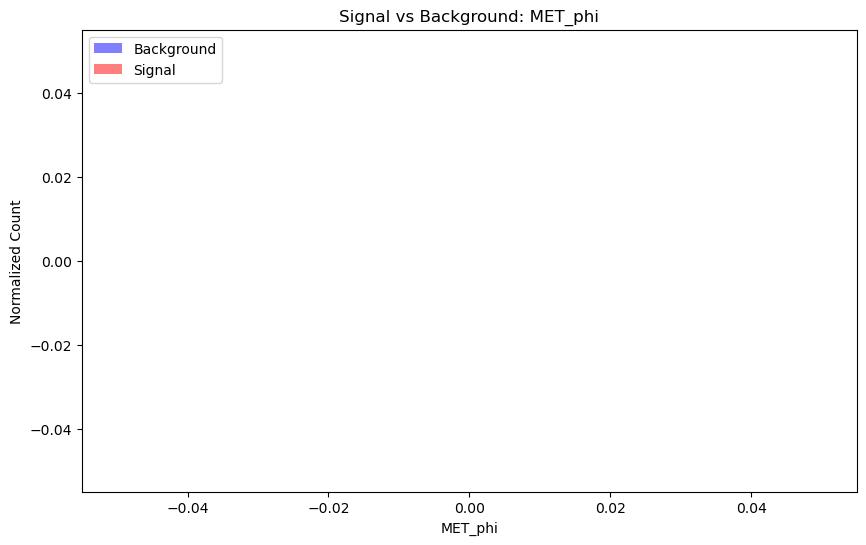

Generating plot for: MET_rel


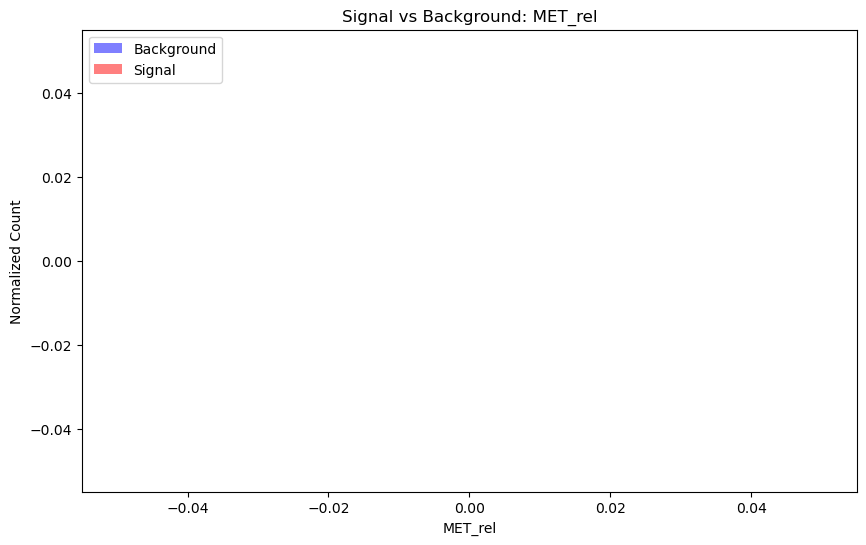

Generating plot for: axial_MET


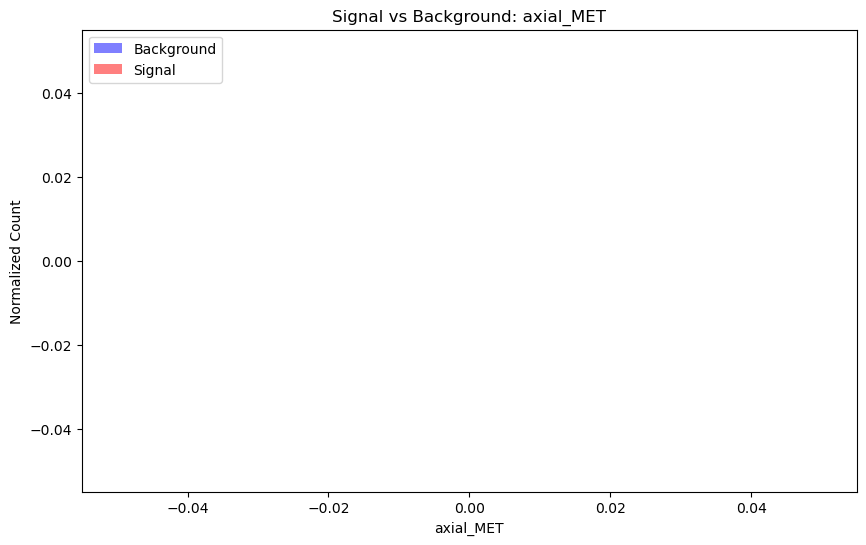

Generating plot for: M_R


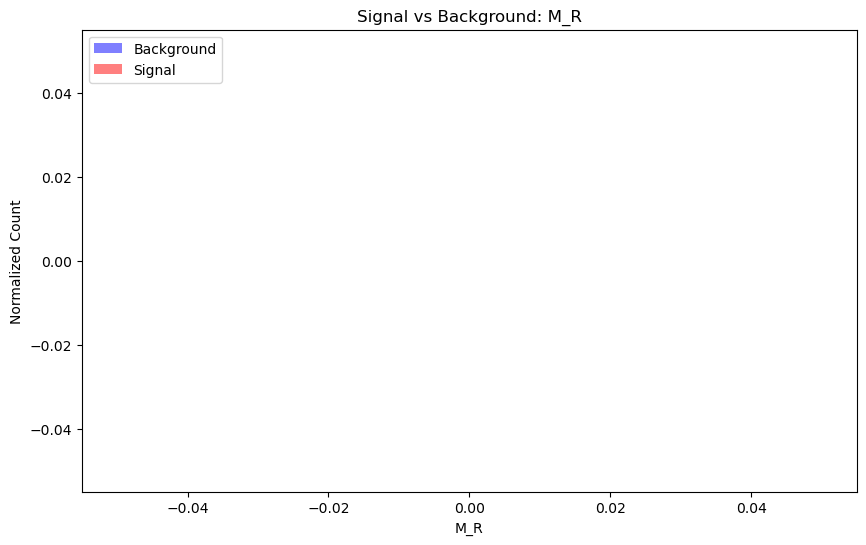

Generating plot for: M_TR_2


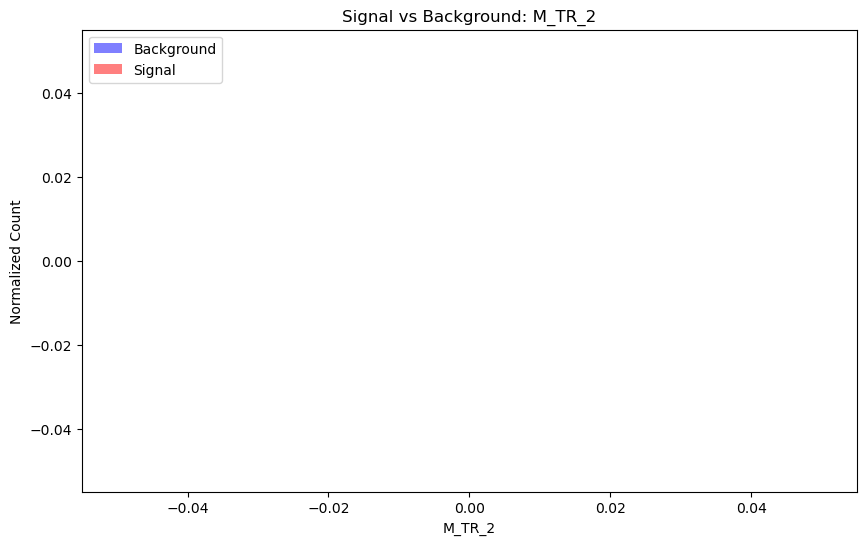

Generating plot for: R


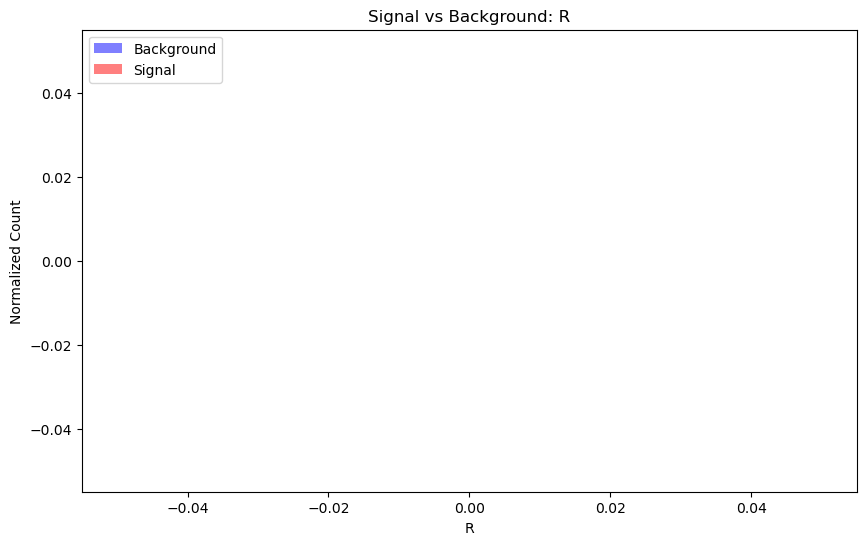

Generating plot for: MT2


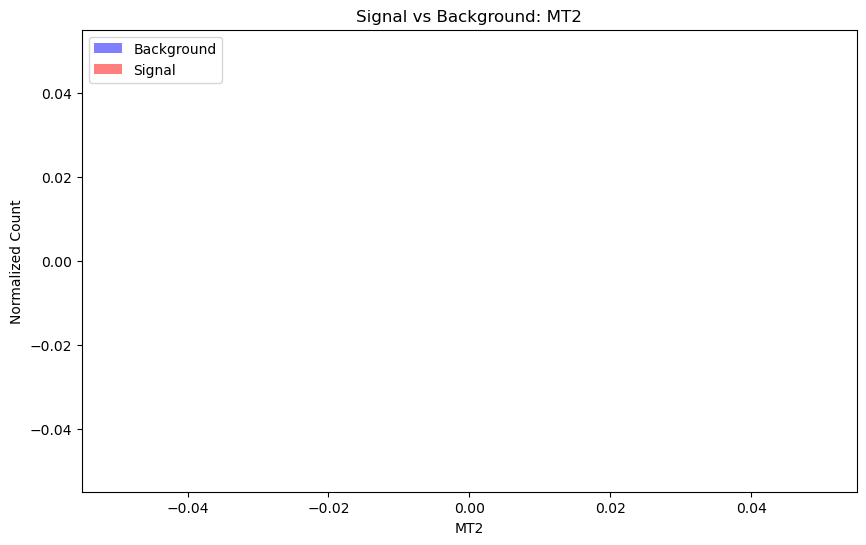

Generating plot for: S_R


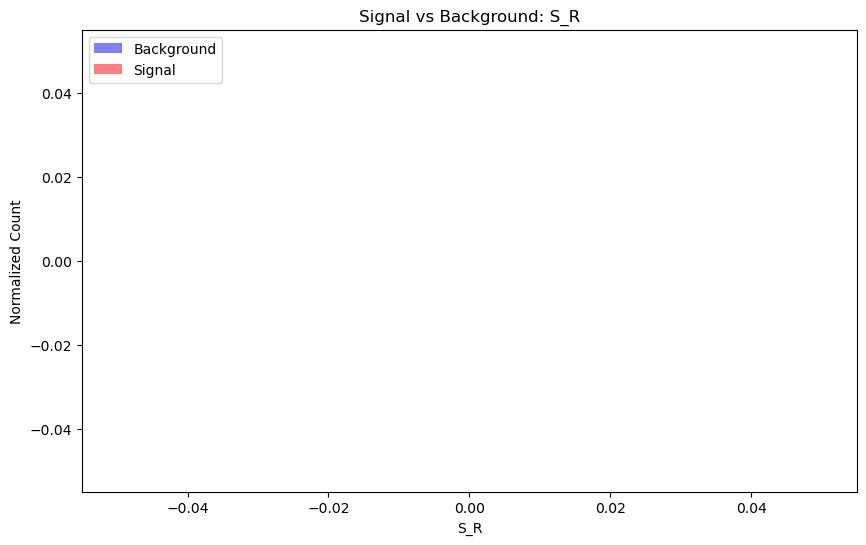

Generating plot for: M_Delta_R


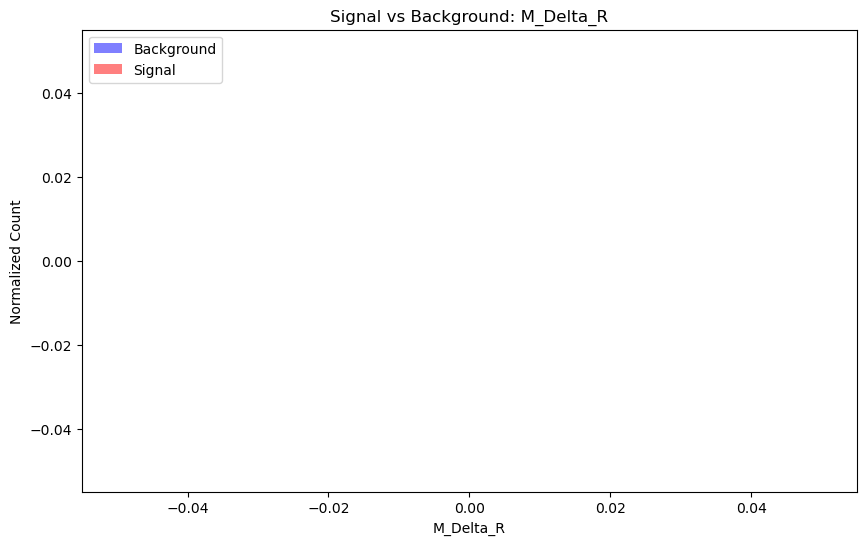

Generating plot for: dPhi_r_b


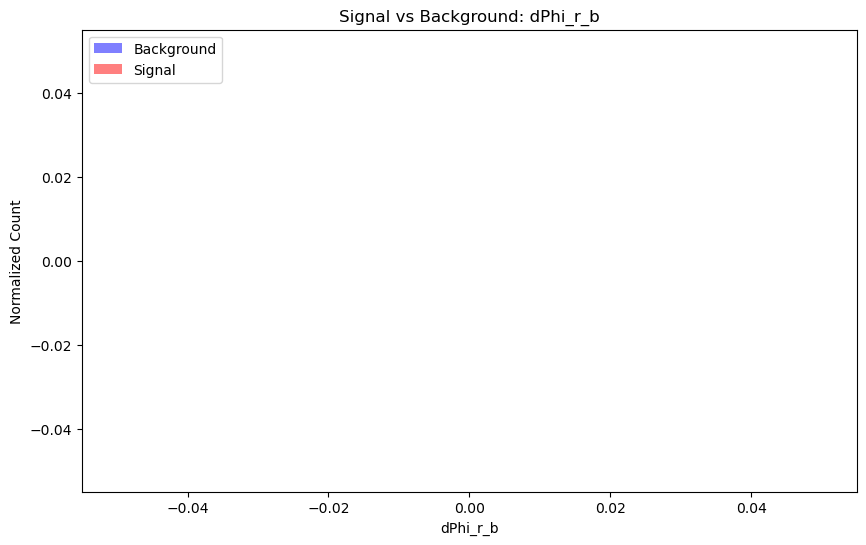

Generating plot for: cos_theta_r1


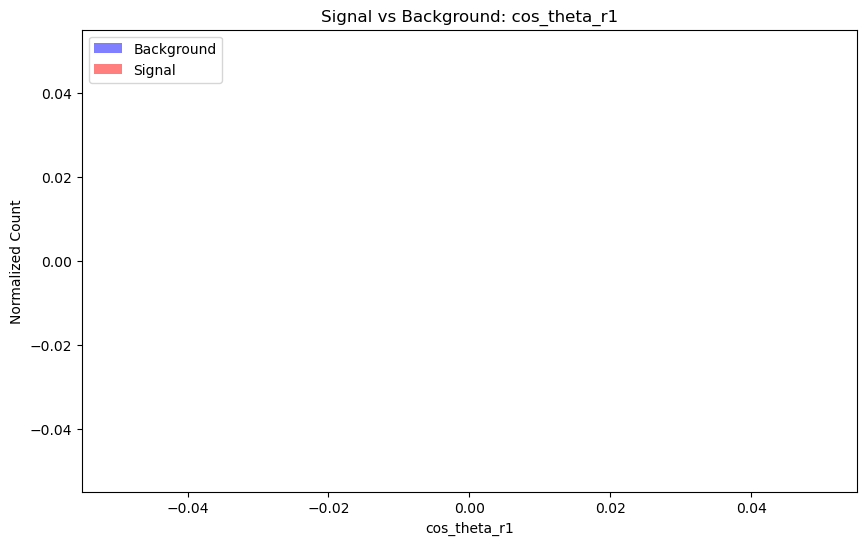

In [6]:
# Loop through all variables (except the 'signal' label itself)
for var in VarNames[1:]:
    print(f"Generating plot for: {var}")
    plt.figure(figsize=(10,6))
    
    # We use density=True to compare the SHAPE, since there are more background events than signal
    plt.hist(df_bkg[var], bins=50, alpha=0.5, label='Background', color='blue', density=True)
    plt.hist(df_sig[var], bins=50, alpha=0.5, label='Signal', color='red', density=True)
    
    plt.title(f'Signal vs Background: {var}')
    plt.xlabel(var)
    plt.ylabel('Normalized Count')
    plt.legend()
    plt.show()


l_1_pT


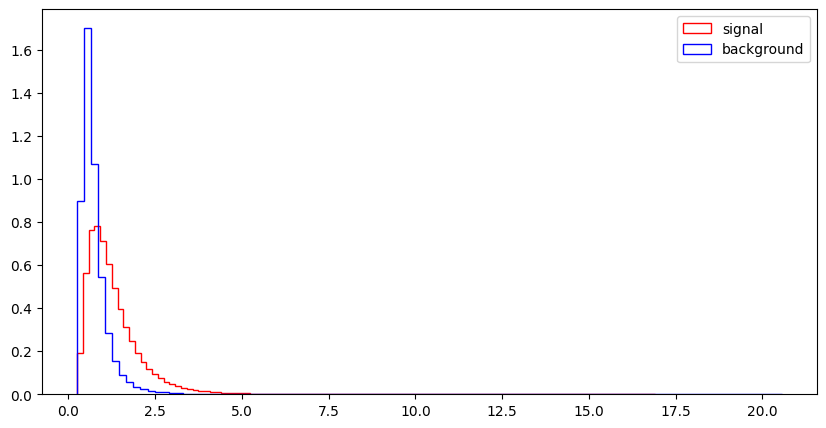

l_1_eta


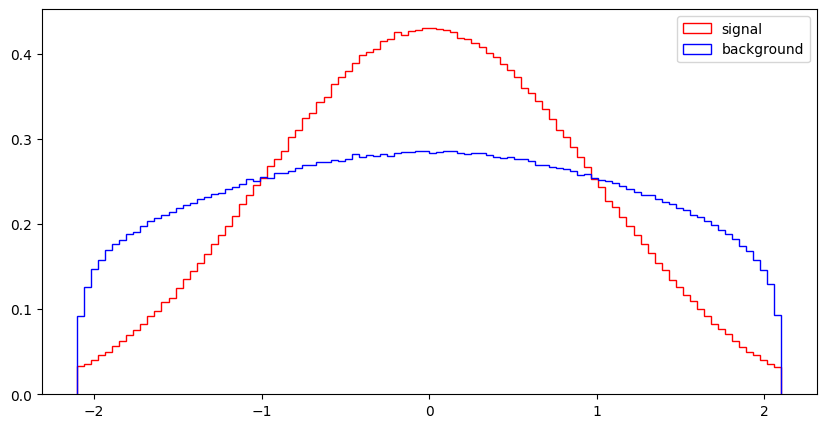

l_1_phi


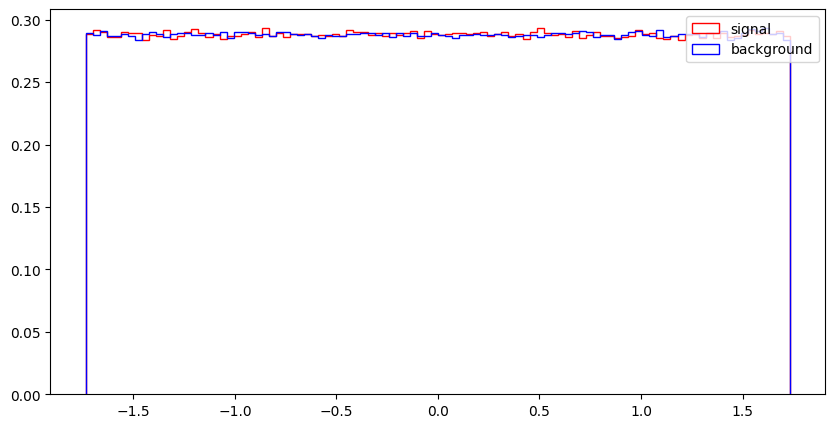

l_2_pT


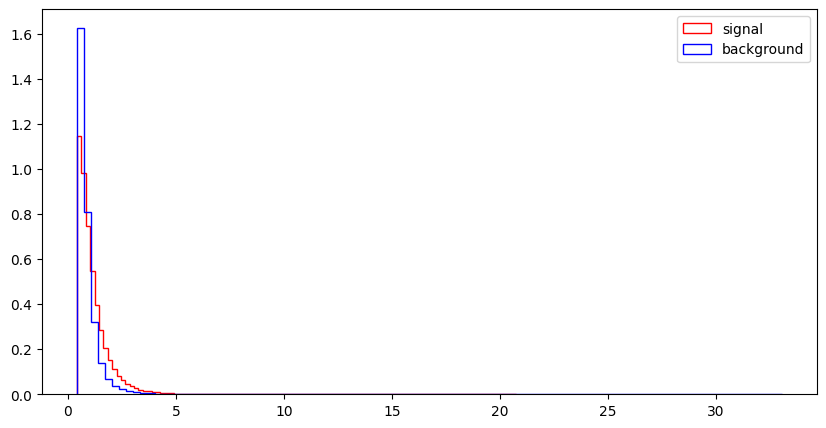

l_2_eta


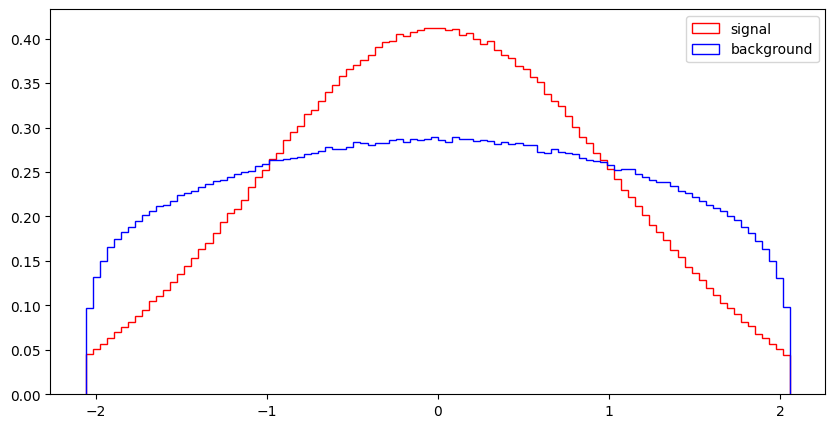

l_2_phi


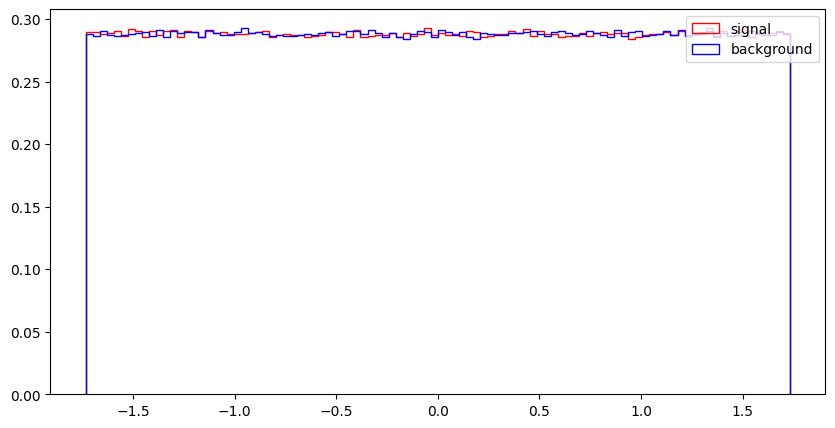

MET


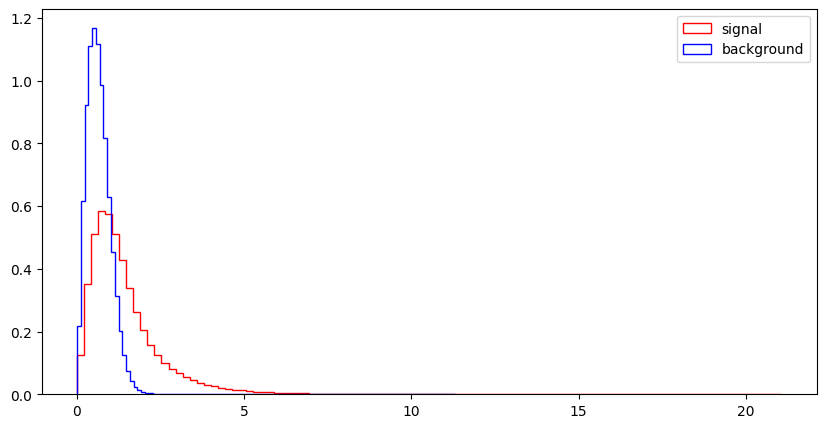

MET_phi


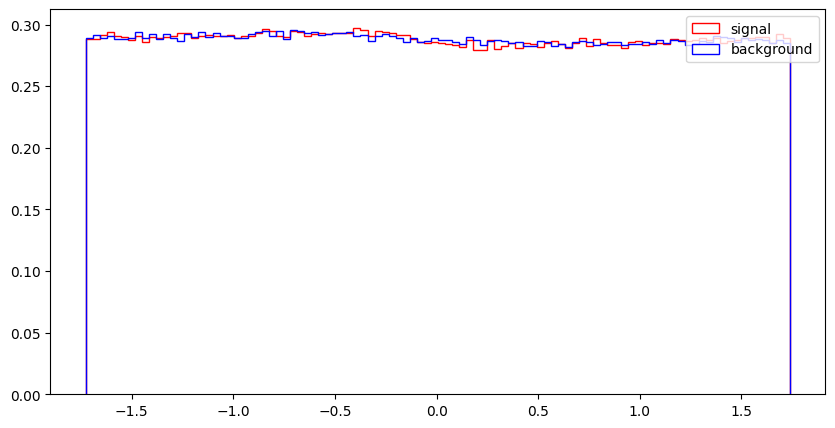

MET_rel


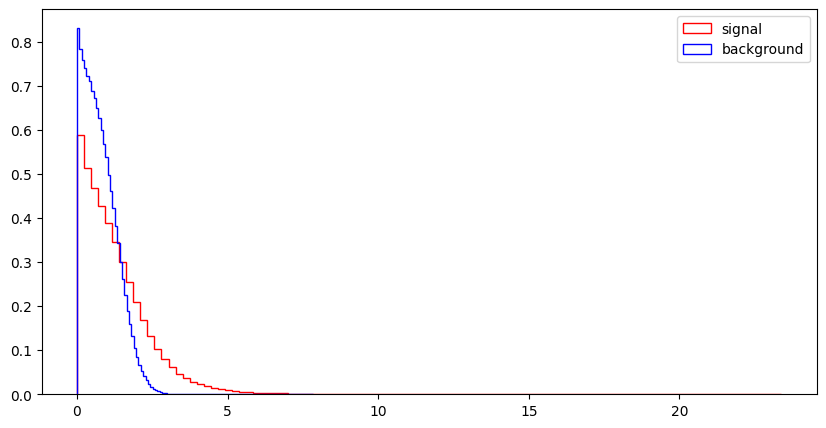

axial_MET


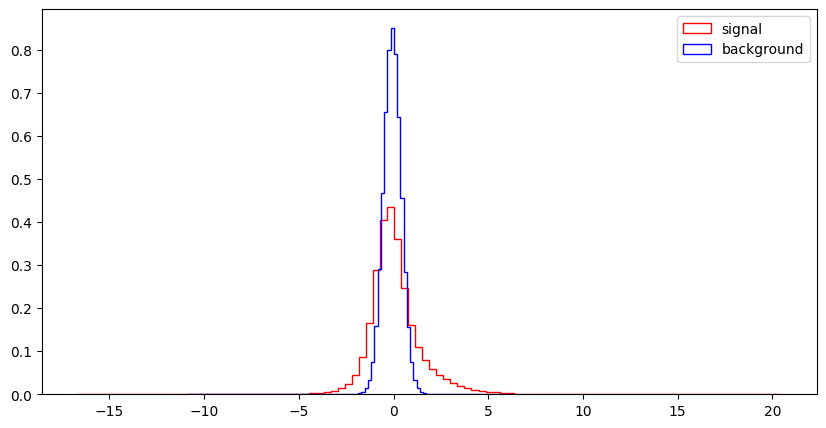

M_R


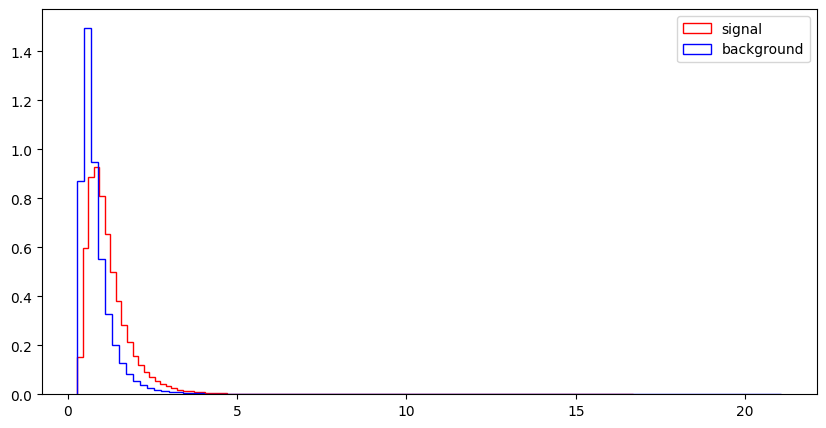

M_TR_2


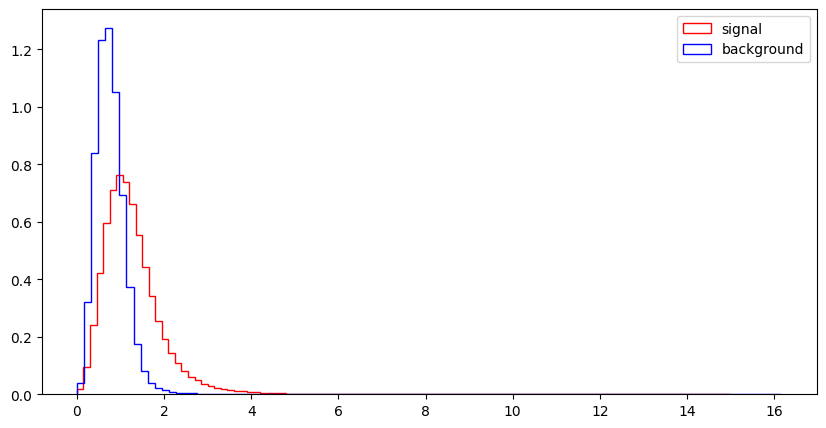

R


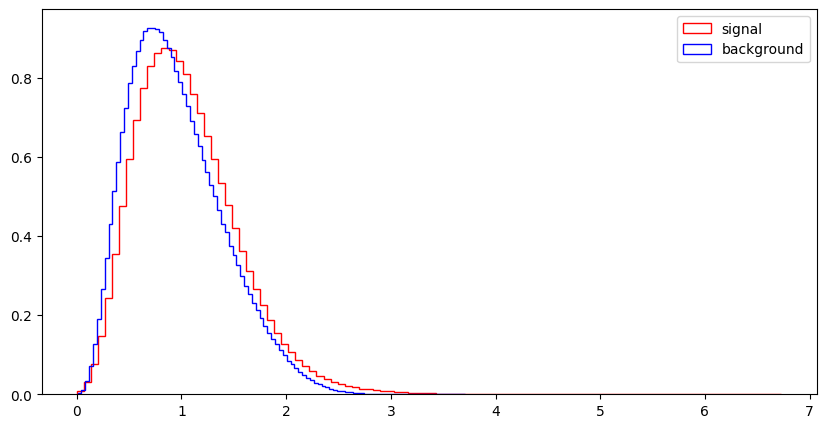

MT2


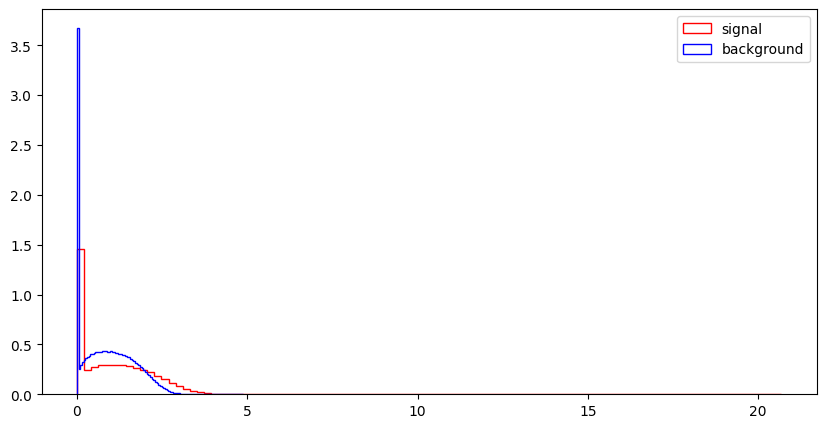

S_R


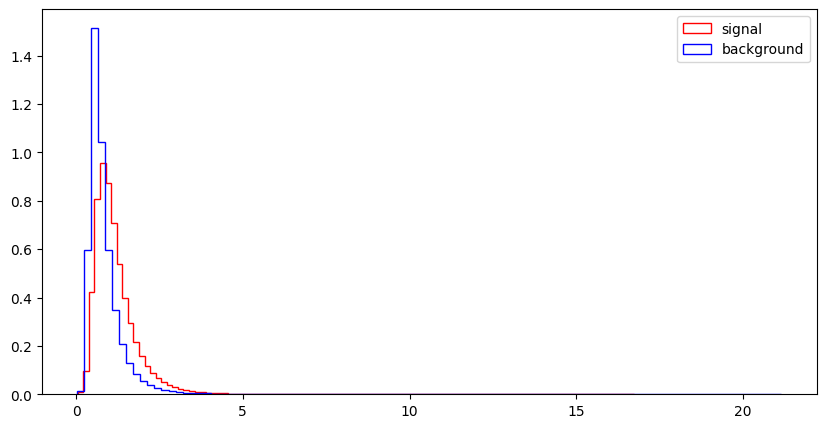

M_Delta_R


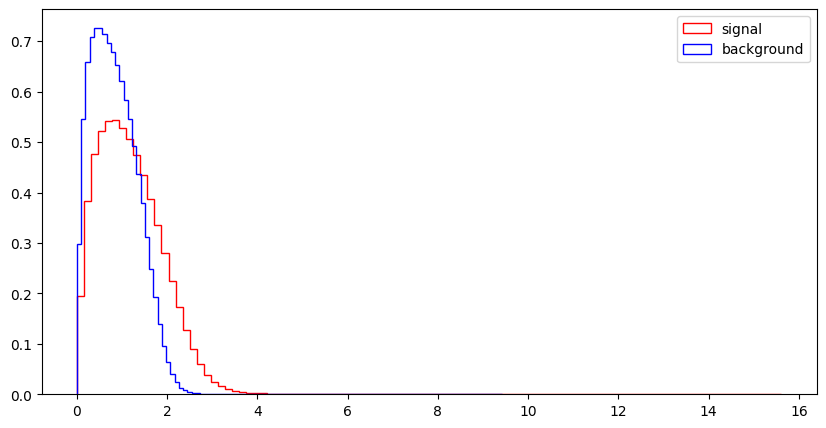

dPhi_r_b


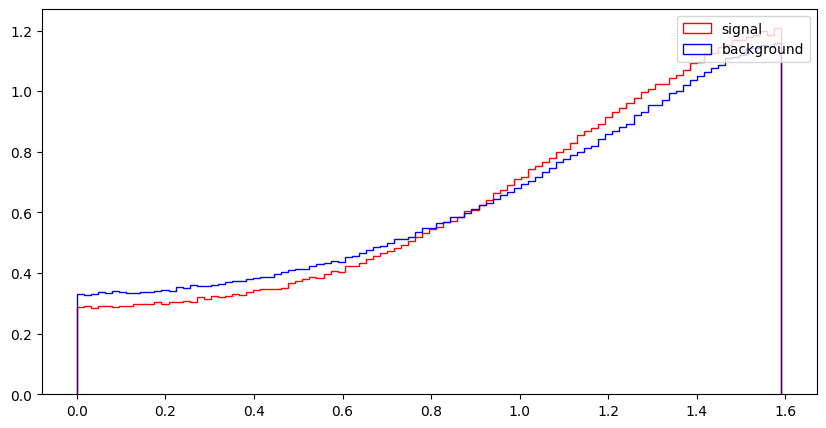

cos_theta_r1


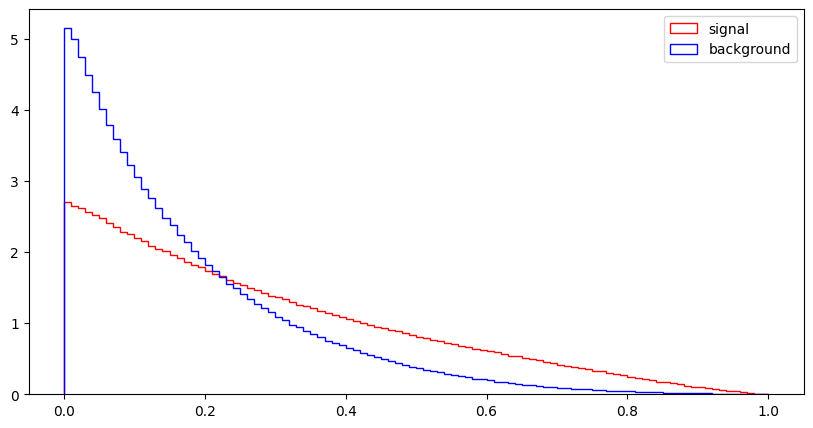

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

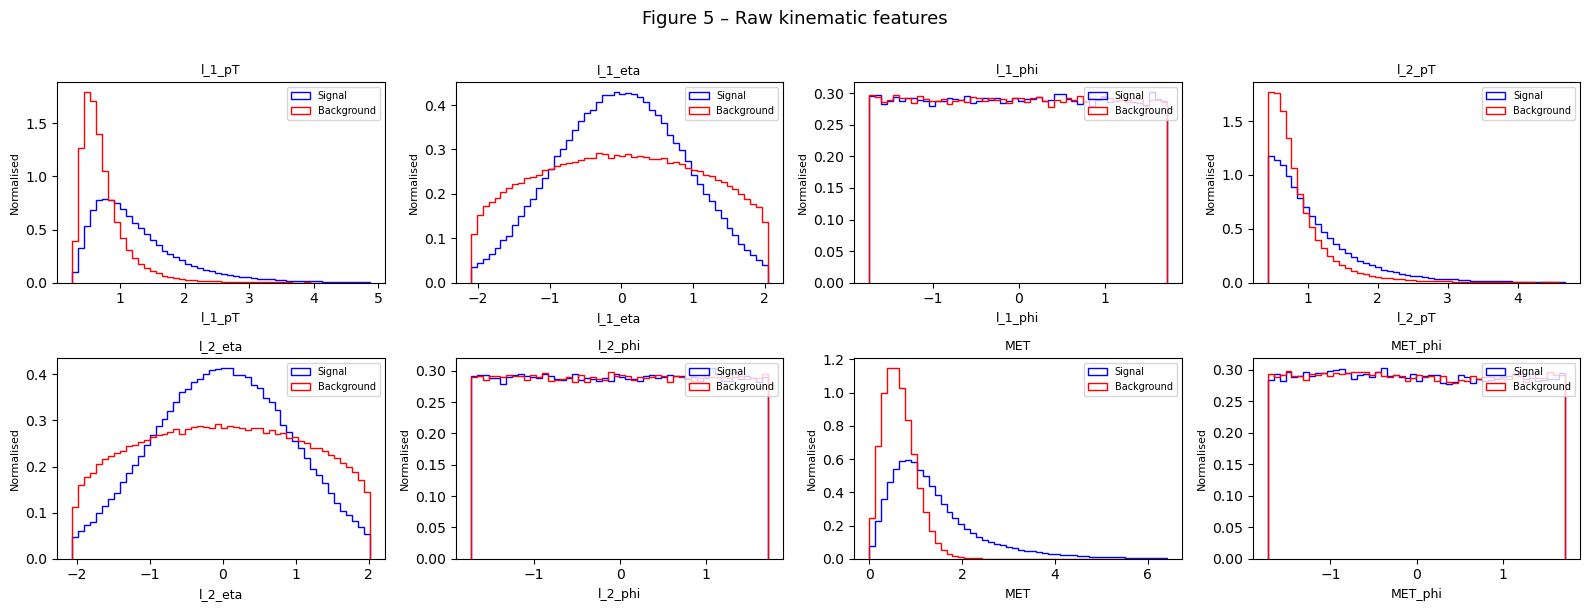

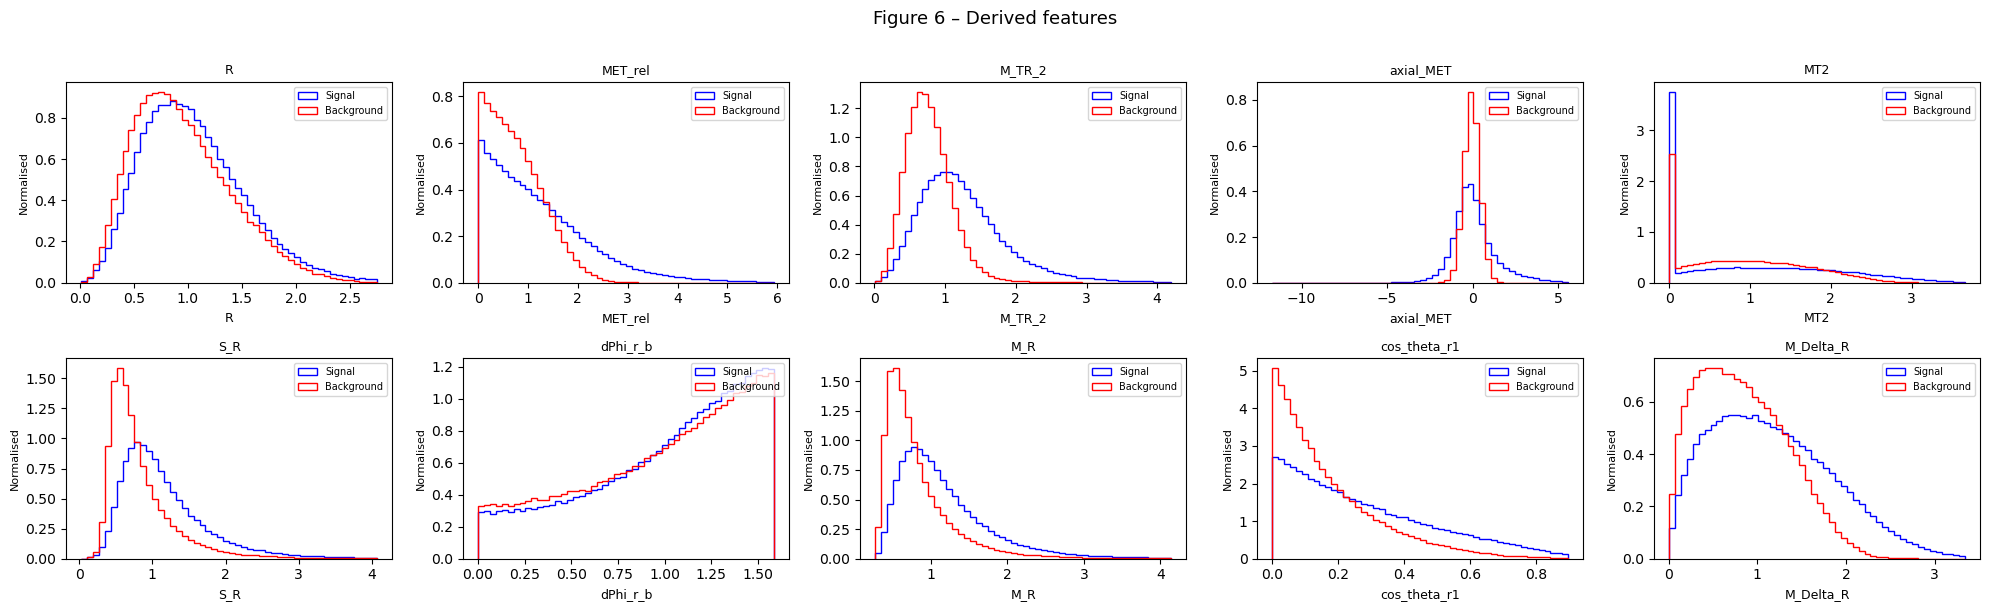

In [8]:
# Exercise 3:-
def plot_variable_grid(var_list, nrows, ncols, title, bins=50):
    """Reproduce paper-style signal/background overlay histograms."""
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
 
    for i, var in enumerate(var_list):
        ax = axes[i]
        lo = min(df_sig[var].min(), df_bkg[var].min())
        hi = max(df_sig[var].quantile(0.995), df_bkg[var].quantile(0.995))
 
        ax.hist(df_sig[var], bins=bins, range=(lo, hi),
                histtype="step", color="blue", density=True, label="Signal")
        ax.hist(df_bkg[var], bins=bins, range=(lo, hi),
                histtype="step", color="red",  density=True, label="Background")
 
        ax.set_xlabel(var, fontsize=9)
        ax.set_ylabel("Normalised", fontsize=8)
        ax.legend(fontsize=7)
        ax.set_title(var, fontsize=9)
 
    # hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
 
# Figure 5- 
plot_variable_grid(RawNames, nrows=2, ncols=4, title="Figure 5 – Raw kinematic features")
 
# Figure 6- 
plot_variable_grid(FeatureNames, nrows=2, ncols=5, title="Figure 6 – Derived features")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

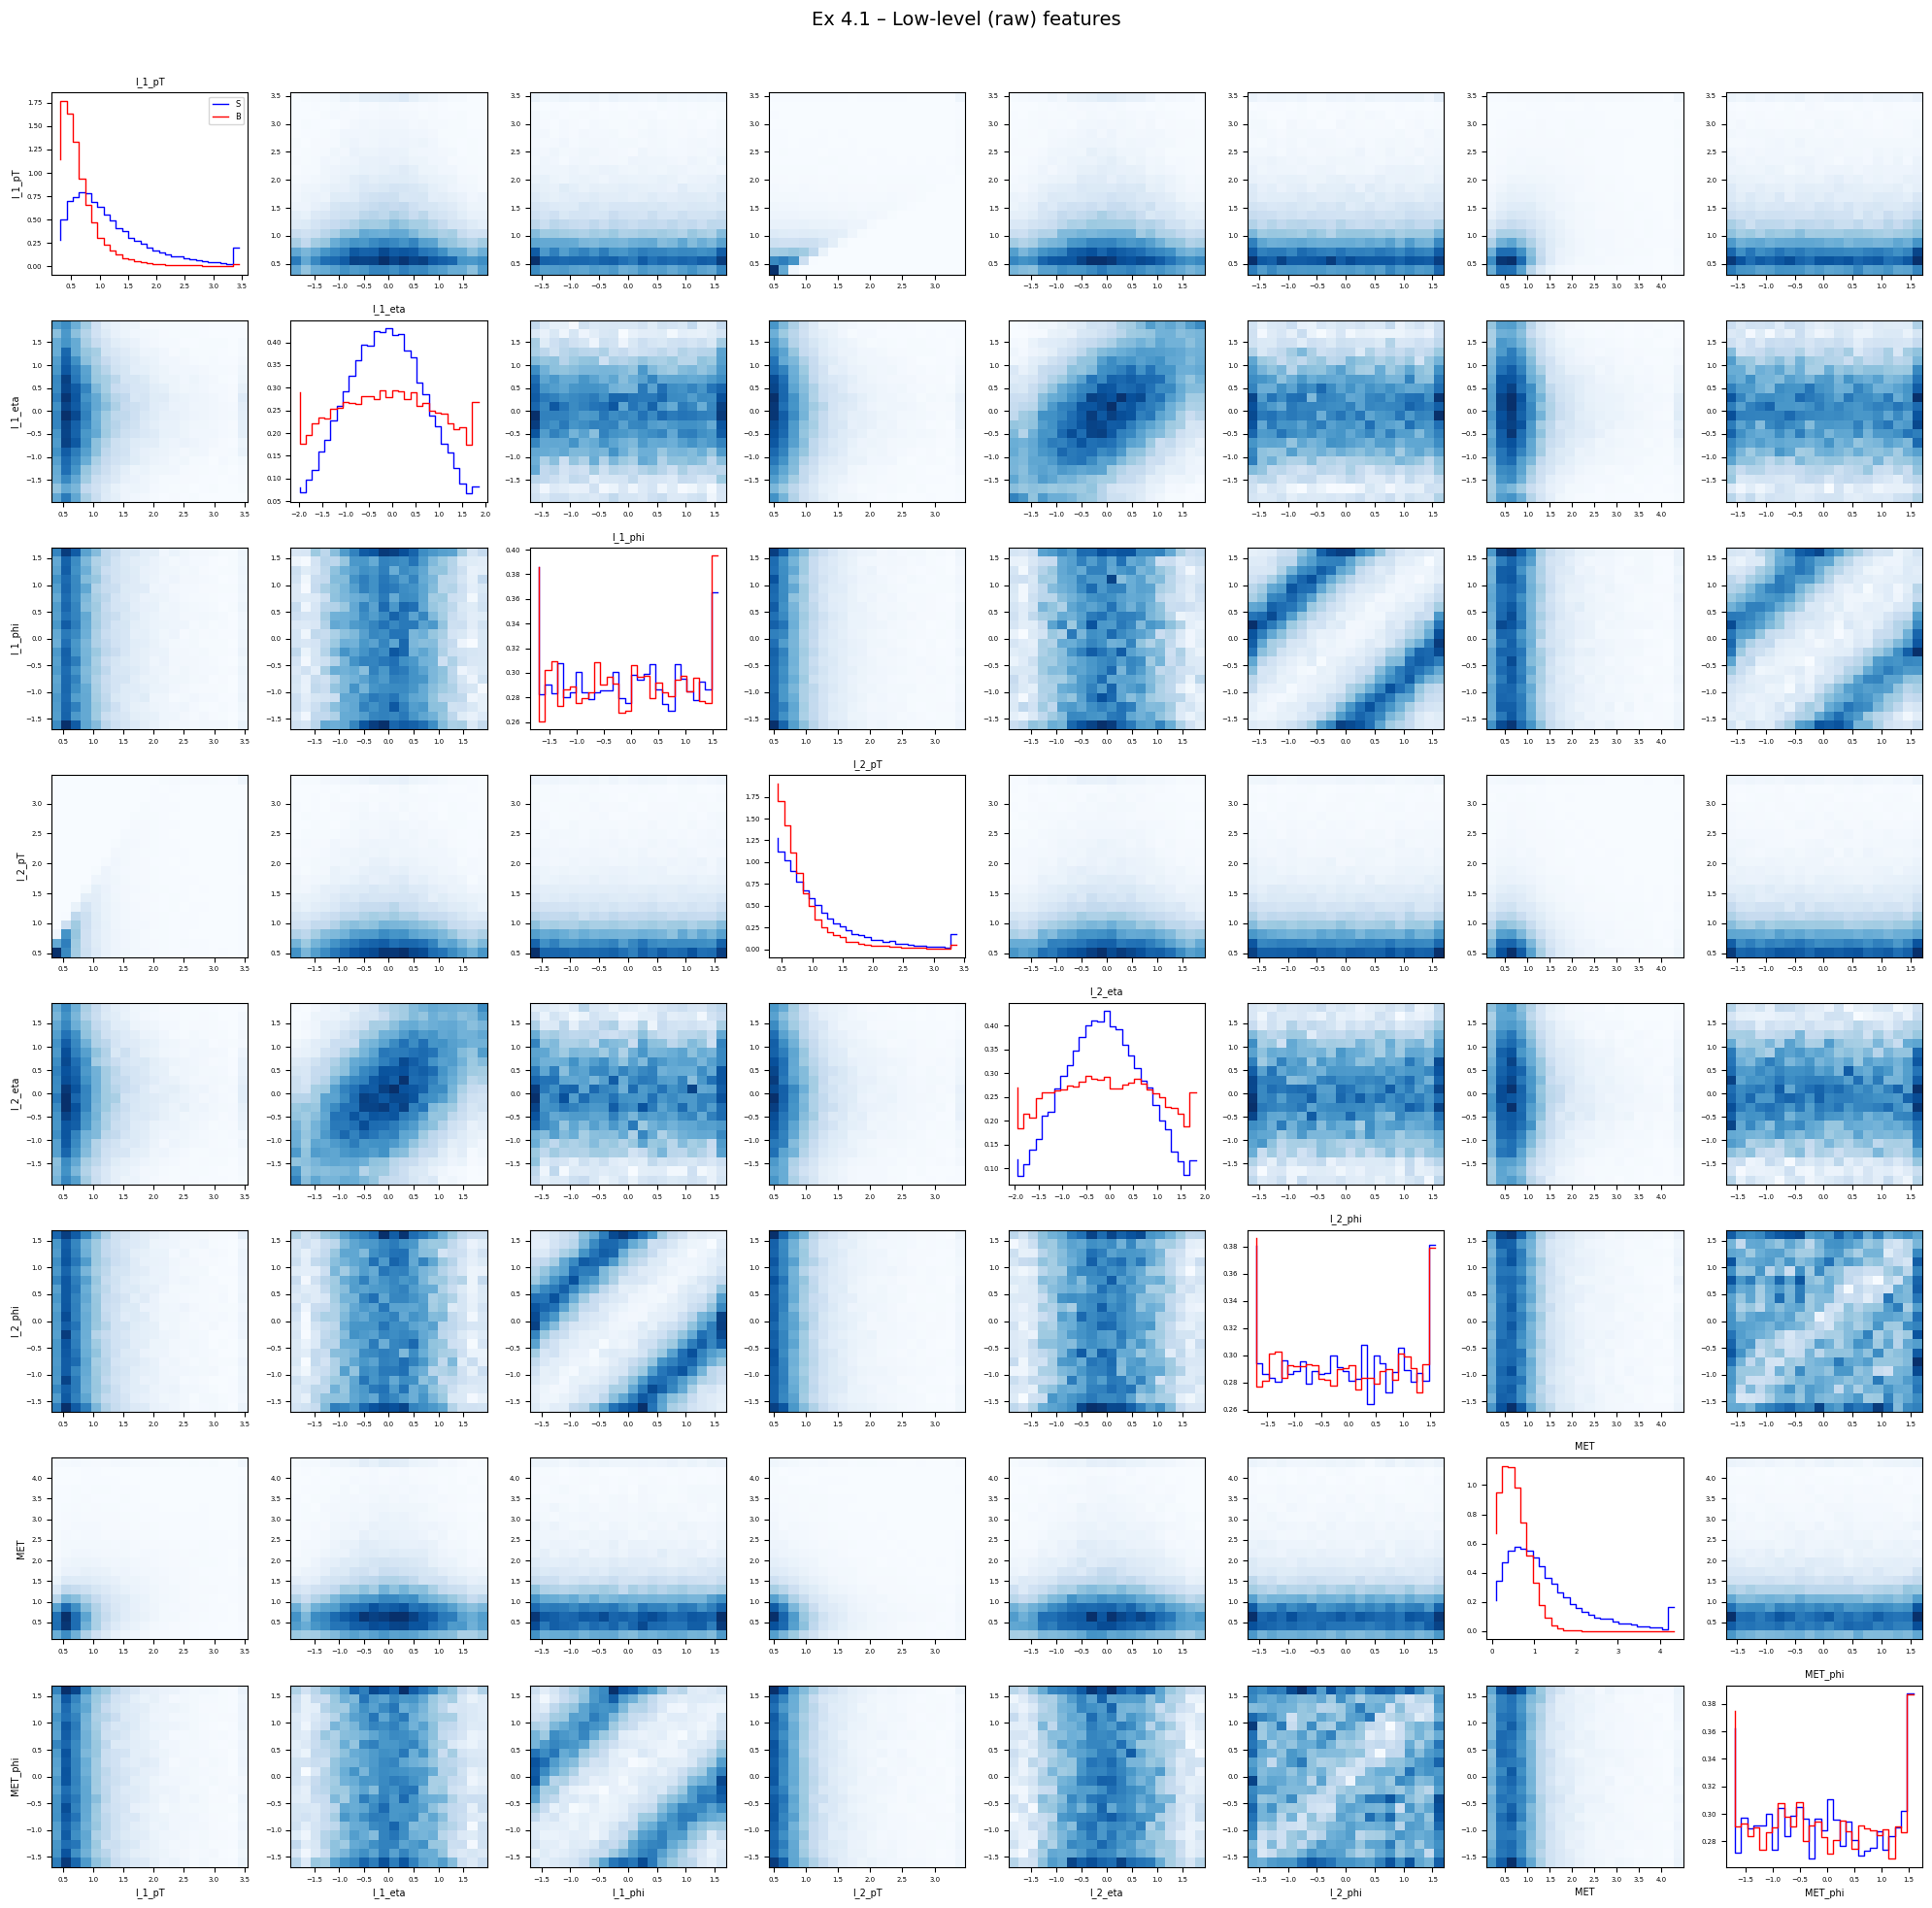

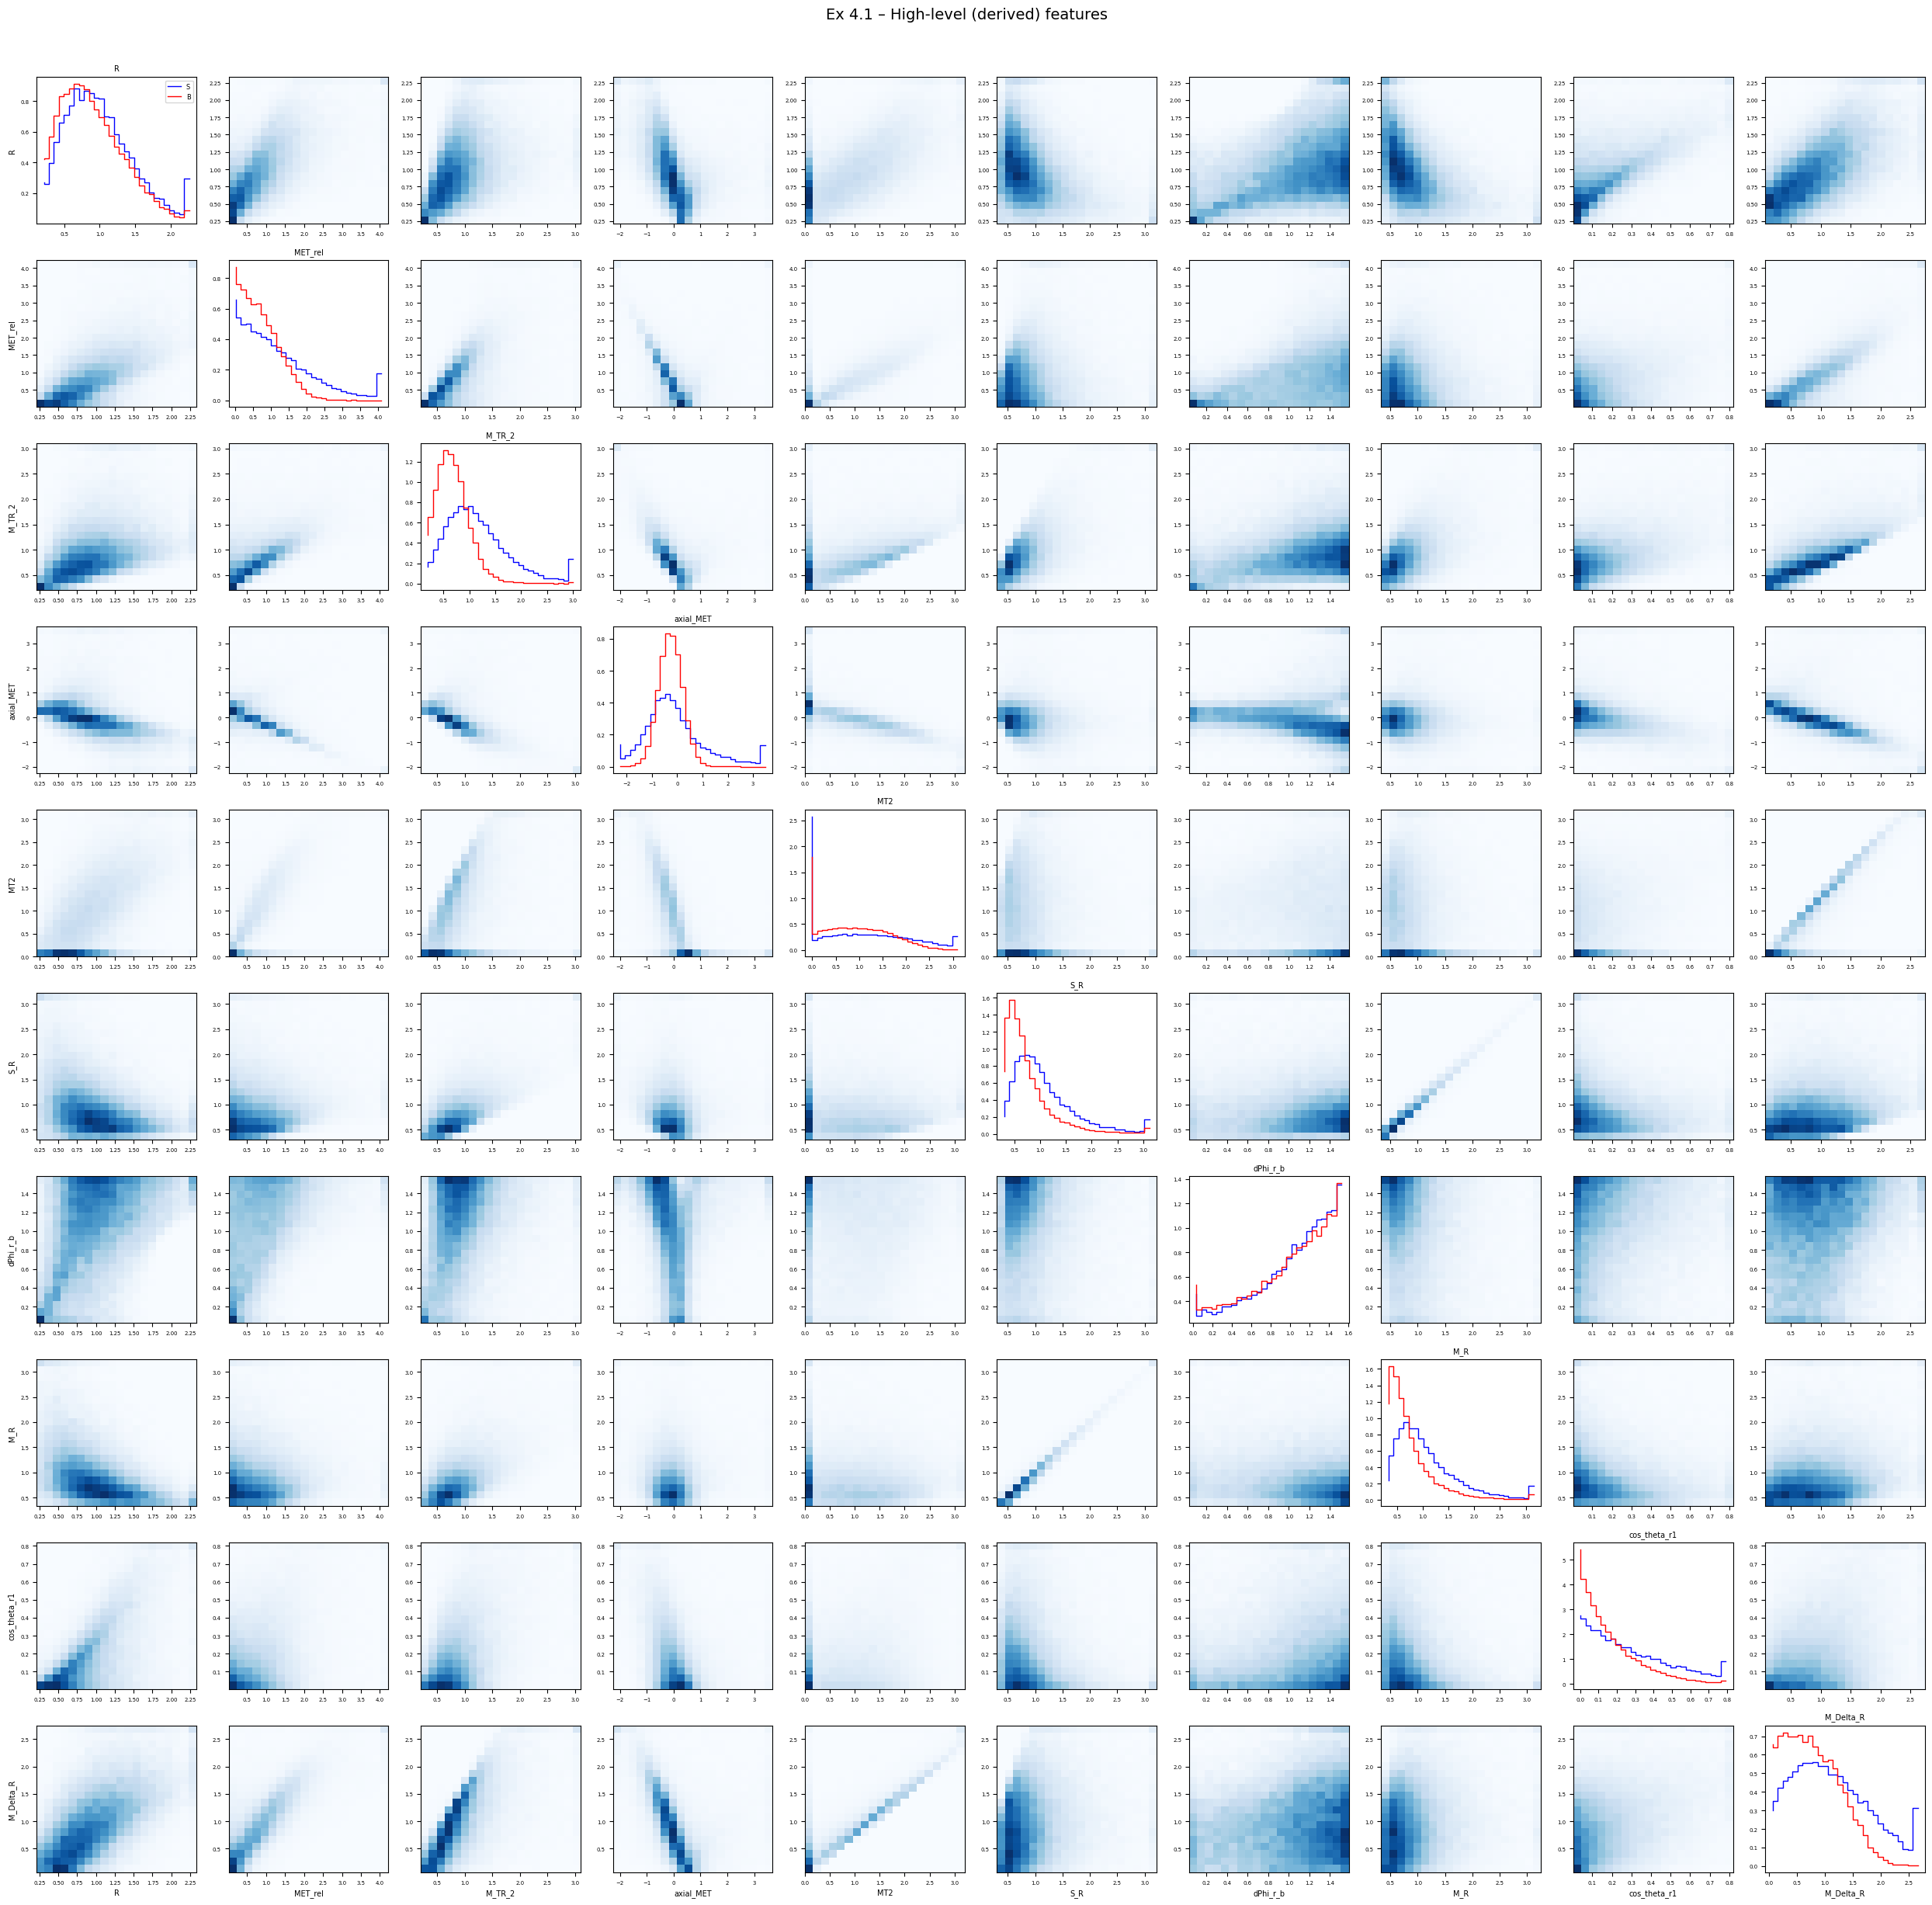

In [10]:
#Part a and b- 
def fast_pair_plot(df, variables, title="Pair plot", sample=50_000, bins=30):
    """
    Part a: pair plot with 1-D histograms on diagonal.
    Part b: speeds things up by:
      1. Pre-computing np.histogram once per variable (not once per subplot).
      2. Using a random subsample for the 2-D scatter / histogram.
      3. Using np.histogram2d directly instead of plt.hist2d
         (avoids redundant data copies inside matplotlib).
    """
    # ── speed-up: subsample once ──────────────────────────────
    rng  = np.random.default_rng(42)
    idx  = rng.choice(len(df), size=min(sample, len(df)), replace=False)
    dfs  = df.iloc[idx]
    sig  = dfs[dfs.signal == 1]
    bkg  = dfs[dfs.signal == 0]
 
    n    = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))
    fig.suptitle(title, fontsize=14)
 
    # ── speed-up: pre-compute 1-D histograms ──────────────────
    hist_sig = {}
    hist_bkg = {}
    edges    = {}
    for v in variables:
        lo = dfs[v].quantile(0.01);  hi = dfs[v].quantile(0.99)
        c_s, e = np.histogram(sig[v].clip(lo, hi), bins=bins, density=True)
        c_b, _ = np.histogram(bkg[v].clip(lo, hi), bins=e,   density=True)
        hist_sig[v] = c_s;  hist_bkg[v] = c_b;  edges[v] = e
 
    for i, vy in enumerate(variables):
        for j, vx in enumerate(variables):
            ax = axes[i, j]
 
            if i == j:                              # diagonal: 1-D histograms
                ax.step(edges[vx][:-1], hist_sig[vx], color="blue",  lw=1, label="S")
                ax.step(edges[vx][:-1], hist_bkg[vx], color="red",   lw=1, label="B")
                ax.set_title(vx, fontsize=7)
                if i == 0:
                    ax.legend(fontsize=6)
            else:                                   # off-diagonal: 2-D histogram
                lo_x = edges[vx][0];  hi_x = edges[vx][-1]
                lo_y = edges[vy][0];  hi_y = edges[vy][-1]
                H, xe, ye = np.histogram2d(
                    dfs[vx].clip(lo_x, hi_x),
                    dfs[vy].clip(lo_y, hi_y),
                    bins=20
                )
                ax.pcolormesh(xe, ye, H.T, cmap="Blues")
 
            if i == n - 1: ax.set_xlabel(vx, fontsize=7)
            if j == 0:     ax.set_ylabel(vy, fontsize=7)
            ax.tick_params(labelsize=5)
 
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
 
fast_pair_plot(df, RawNames,     title="Ex 4.1 – Low-level (raw) features")
fast_pair_plot(df, FeatureNames, title="Ex 4.1 – High-level (derived) features")

In [11]:
# Part c – 
from scipy.spatial.distance import jensenshannon

separations = {}
for var in VarNames[1:]:
    lo = df[var].quantile(0.01)
    hi = df[var].quantile(0.99)
    bins = np.linspace(lo, hi, 60)

    p, _ = np.histogram(df_sig[var].clip(lo, hi), bins=bins, density=True)
    q, _ = np.histogram(df_bkg[var].clip(lo, hi), bins=bins, density=True)

    # avoid zeros
    p = p + 1e-10
    q = q + 1e-10
    separations[var] = jensenshannon(p, q)

# Sort and print
ranked = sorted(separations.items(), key=lambda x: x[1], reverse=True)

print("Variable separation ranking (Jensen-Shannon divergence, higher = better):\n")
for rank, (var, score) in enumerate(ranked, 1):
    bar = "█" * int(score * 200)
    print(f"  {rank:>2}. {var:<15}  {score:.4f}  {bar}")

Variable separation ranking (Jensen-Shannon divergence, higher = better):

   1. MET              0.3843  ████████████████████████████████████████████████████████████████████████████
   2. M_TR_2           0.3491  █████████████████████████████████████████████████████████████████████
   3. l_1_pT           0.3367  ███████████████████████████████████████████████████████████████████
   4. axial_MET        0.3284  █████████████████████████████████████████████████████████████████
   5. M_R              0.2596  ███████████████████████████████████████████████████
   6. S_R              0.2532  ██████████████████████████████████████████████████
   7. MET_rel          0.2388  ███████████████████████████████████████████████
   8. M_Delta_R        0.2171  ███████████████████████████████████████████
   9. cos_theta_r1     0.1914  ██████████████████████████████████████
  10. MT2              0.1823  ████████████████████████████████████
  11. l_2_pT           0.1628  ████████████████████████████████

In [9]:
df = pd.read_csv("SUSY.csv", names=VarNames, nrows=500000)

FileNotFoundError: [Errno 2] No such file or directory: 'SUSY.csv'

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [13]:
!pip install tabulate --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [14]:
import numpy as np
from IPython.display import HTML, display
import tabulate as tab

def display_matrices(dataset, features, title):
    data = dataset[features].dropna().values.astype(float)

    cov_mat  = np.cov(data, rowvar=False)
    corr_mat = np.corrcoef(data, rowvar=False)

    def make_html_table(mat, feat, caption):
        rows    = [[f] + [f"{mat[i,j]:.3g}" for j in range(len(feat))]
                   for i, f in enumerate(feat)]
        headers = [""] + feat
        table_html = tab.tabulate(rows, headers=headers, tablefmt="html")
        styled = f"""
        <div style="margin: 20px 0;">
            <h4 style="font-family: sans-serif; margin-bottom: 6px;">{caption}</h4>
            <style>
                .matTable table {{ border-collapse: collapse; font-size: 11px; font-family: monospace; }}
                .matTable th, .matTable td {{ border: 1px solid #ccc; padding: 4px 8px; text-align: right; }}
                .matTable th {{ background-color: #f0f0f0; font-weight: bold; text-align: center; }}
            </style>
            <div class="matTable">{table_html}</div>
        </div>
        """
        return styled

    print(f"\n{'═'*60}\n  {title}\n{'═'*60}")
    display(HTML(make_html_table(cov_mat,  features, f"Covariance matrix – {title}")))
    display(HTML(make_html_table(corr_mat, features, f"Correlation matrix – {title}")))


display_matrices(df, VarNames[1:],  "All observables")
display_matrices(df, RawNames,      "Low-level (raw) features")
display_matrices(df, FeatureNames,  "High-level (derived) features")


════════════════════════════════════════════════════════════
  All observables
════════════════════════════════════════════════════════════


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937,0.0975,-0.00973,0.364,0.287,-0.0597,-0.0124,0.343,0.0977,-0.0469,0.0222
l_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589,-0.00137,-0.00111,-0.000554,-0.000669,0.000301,0.000427,-0.000604,-0.000987,-0.00074,0.000322
l_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185,0.000706,-0.00187,0.00106,0.000869,0.000202,0.00106,0.00146,0.000901,0.000994,0.000259
l_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156,-0.000534,0.0513,0.325,0.163,-0.0994,-0.0689,0.322,0.00572,-0.00383,-0.0279
l_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322,0.00108,-0.000756,-0.000608,1.89e-05,0.000321,0.0014,-0.000679,0.00067,-0.000307,0.000296
l_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354,0.00145,-0.0018,0.00076,0.000509,0.000551,0.00226,0.000906,0.00133,-0.000241,3.7e-05
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.0731
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1,-0.0049,-0.000442,-0.00148,-0.0012,-0.00023,8.39e-05,-0.00171,-0.00057,-0.00171,0.000119
MET_rel,0.0975,-0.00137,0.000706,-0.000534,0.00108,0.00145,0.546,-0.0049,0.79,-0.12,0.0437,0.302,0.249,0.409,0.0823,0.415,0.146,0.0553
axial_MET,-0.00973,-0.00111,-0.00187,0.0513,-0.000756,-0.0018,0.154,-0.000442,-0.12,1.01,0.0171,-0.185,-0.181,-0.461,-0.0414,-0.233,-0.0251,-0.0537


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137,0.16,-0.0142,0.851,0.723,-0.186,-0.0211,0.811,0.229,-0.157,0.165
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587,-0.00154,-0.0011,-0.000882,-0.00115,0.000639,0.000496,-0.000975,-0.00158,-0.00169,0.00163
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184,0.000793,-0.00186,0.00169,0.00149,0.000427,0.00123,0.00236,0.00144,0.00228,0.00131
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239,-0.000921,0.0785,0.797,0.43,-0.324,-0.123,0.799,0.0141,-0.0135,-0.217
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321,0.00122,-0.000752,-0.000967,3.24e-05,0.000679,0.00162,-0.00109,0.00107,-0.000701,0.0015
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353,0.00162,-0.00179,0.00121,0.000874,0.00117,0.00263,0.00146,0.00212,-0.000552,0.000188
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1,-0.0055,-0.00044,-0.00236,-0.00206,-0.000487,9.75e-05,-0.00276,-0.000913,-0.00391,0.000605
MET_rel,0.16,-0.00154,0.000793,-0.000921,0.00122,0.00162,0.704,-0.0055,1,-0.134,0.0785,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.0142,-0.0011,-0.00186,0.0785,-0.000752,-0.00179,0.176,-0.00044,-0.134,1,0.0273,-0.317,-0.383,-0.535,-0.0668,-0.373,-0.0574,-0.272



════════════════════════════════════════════════════════════
  Low-level (raw) features
════════════════════════════════════════════════════════════


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937
l_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589
l_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185
l_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156
l_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322
l_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1



════════════════════════════════════════════════════════════
  High-level (derived) features
════════════════════════════════════════════════════════════


,R,MET_rel,M_TR_2,axial_MET,MT2,S_R,dPhi_r_b,M_R,cos_theta_r1,M_Delta_R
R,0.222,0.249,0.104,-0.181,0.232,-0.0834,0.0871,-0.113,0.0582,0.165
MET_rel,0.249,0.79,0.302,-0.12,0.409,0.0823,0.146,0.0437,0.0553,0.415
M_TR_2,0.104,0.302,0.338,-0.185,0.189,0.228,0.0581,0.21,0.0517,0.242
axial_MET,-0.181,-0.12,-0.185,1.01,-0.461,-0.0414,-0.0251,0.0171,-0.0537,-0.233
MT2,0.232,0.409,0.189,-0.461,0.738,-0.011,0.0209,-0.0365,0.0446,0.433
S_R,-0.0834,0.0823,0.228,-0.0414,-0.011,0.382,-0.00346,0.38,-0.0104,0.0958
dPhi_r_b,0.0871,0.146,0.0581,-0.0251,0.0209,-0.00346,0.19,-0.029,0.00908,0.0422
M_R,-0.113,0.0437,0.21,0.0171,-0.0365,0.38,-0.029,0.392,-0.0143,0.0739
cos_theta_r1,0.0582,0.0553,0.0517,-0.0537,0.0446,-0.0104,0.00908,-0.0143,0.0388,0.0392
M_Delta_R,0.165,0.415,0.242,-0.233,0.433,0.0958,0.0422,0.0739,0.0392,0.389


,R,MET_rel,M_TR_2,axial_MET,MT2,S_R,dPhi_r_b,M_R,cos_theta_r1,M_Delta_R
R,1,0.595,0.38,-0.383,0.574,-0.287,0.424,-0.383,0.627,0.564
MET_rel,0.595,1,0.584,-0.134,0.535,0.15,0.378,0.0785,0.316,0.748
M_TR_2,0.38,0.584,1,-0.317,0.379,0.635,0.229,0.577,0.451,0.668
axial_MET,-0.383,-0.134,-0.317,1,-0.535,-0.0668,-0.0574,0.0273,-0.272,-0.373
MT2,0.574,0.535,0.379,-0.535,1,-0.0208,0.0558,-0.0679,0.264,0.809
S_R,-0.287,0.15,0.635,-0.0668,-0.0208,1,-0.0128,0.981,-0.0851,0.249
dPhi_r_b,0.424,0.378,0.229,-0.0574,0.0558,-0.0128,1,-0.106,0.106,0.155
M_R,-0.383,0.0785,0.577,0.0273,-0.0679,0.981,-0.106,1,-0.116,0.189
cos_theta_r1,0.627,0.316,0.451,-0.272,0.264,-0.0851,0.106,-0.116,1,0.319
M_Delta_R,0.564,0.748,0.668,-0.373,0.809,0.249,0.155,0.189,0.319,1


In [15]:
# Part d – reusable function
# Arguments:
#   dataset  : a pandas DataFrame
#   features : list of column names to include
#   title    : string label shown in the heading

def display_matrices(dataset, features, title):
    data = dataset[features].dropna().values.astype(float)

    cov_mat  = np.cov(data, rowvar=False)       # Part b
    corr_mat = np.corrcoef(data, rowvar=False)  # Part b

    def make_html_table(mat, feat, caption):
        rows    = [[f] + [f"{mat[i,j]:.3g}" for j in range(len(feat))]
                   for i, f in enumerate(feat)]
        headers = [""] + feat
        table_html = tab.tabulate(rows, headers=headers, tablefmt="html")
        styled = f"""
        <div style="margin: 20px 0;">
            <h4 style="font-family: sans-serif; margin-bottom: 6px;">{caption}</h4>
            <style>
                .matTable table {{ border-collapse: collapse; font-size: 11px; font-family: monospace; }}
                .matTable th, .matTable td {{ border: 1px solid #ccc; padding: 4px 8px; text-align: right; }}
                .matTable th {{ background-color: #f0f0f0; font-weight: bold; text-align: center; }}
            </style>
            <div class="matTable">{table_html}</div>
        </div>
        """
        return styled

    print(f"\n{'═'*60}\n  {title}\n{'═'*60}")
    display(HTML(make_html_table(cov_mat,  features, f"Covariance matrix – {title}")))   # Part c
    display(HTML(make_html_table(corr_mat, features, f"Correlation matrix – {title}")))  # Part c

# Example calls demonstrating the function works for any subset
display_matrices(df, VarNames[1:],  "All observables")
display_matrices(df, RawNames,      "Low-level (raw) features")
display_matrices(df, FeatureNames,  "High-level (derived) features")


════════════════════════════════════════════════════════════
  All observables
════════════════════════════════════════════════════════════


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937,0.0975,-0.00973,0.364,0.287,-0.0597,-0.0124,0.343,0.0977,-0.0469,0.0222
l_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589,-0.00137,-0.00111,-0.000554,-0.000669,0.000301,0.000427,-0.000604,-0.000987,-0.00074,0.000322
l_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185,0.000706,-0.00187,0.00106,0.000869,0.000202,0.00106,0.00146,0.000901,0.000994,0.000259
l_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156,-0.000534,0.0513,0.325,0.163,-0.0994,-0.0689,0.322,0.00572,-0.00383,-0.0279
l_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322,0.00108,-0.000756,-0.000608,1.89e-05,0.000321,0.0014,-0.000679,0.00067,-0.000307,0.000296
l_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354,0.00145,-0.0018,0.00076,0.000509,0.000551,0.00226,0.000906,0.00133,-0.000241,3.7e-05
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.0731
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1,-0.0049,-0.000442,-0.00148,-0.0012,-0.00023,8.39e-05,-0.00171,-0.00057,-0.00171,0.000119
MET_rel,0.0975,-0.00137,0.000706,-0.000534,0.00108,0.00145,0.546,-0.0049,0.79,-0.12,0.0437,0.302,0.249,0.409,0.0823,0.415,0.146,0.0553
axial_MET,-0.00973,-0.00111,-0.00187,0.0513,-0.000756,-0.0018,0.154,-0.000442,-0.12,1.01,0.0171,-0.185,-0.181,-0.461,-0.0414,-0.233,-0.0251,-0.0537


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137,0.16,-0.0142,0.851,0.723,-0.186,-0.0211,0.811,0.229,-0.157,0.165
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587,-0.00154,-0.0011,-0.000882,-0.00115,0.000639,0.000496,-0.000975,-0.00158,-0.00169,0.00163
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184,0.000793,-0.00186,0.00169,0.00149,0.000427,0.00123,0.00236,0.00144,0.00228,0.00131
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239,-0.000921,0.0785,0.797,0.43,-0.324,-0.123,0.799,0.0141,-0.0135,-0.217
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321,0.00122,-0.000752,-0.000967,3.24e-05,0.000679,0.00162,-0.00109,0.00107,-0.000701,0.0015
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353,0.00162,-0.00179,0.00121,0.000874,0.00117,0.00263,0.00146,0.00212,-0.000552,0.000188
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1,-0.0055,-0.00044,-0.00236,-0.00206,-0.000487,9.75e-05,-0.00276,-0.000913,-0.00391,0.000605
MET_rel,0.16,-0.00154,0.000793,-0.000921,0.00122,0.00162,0.704,-0.0055,1,-0.134,0.0785,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.0142,-0.0011,-0.00186,0.0785,-0.000752,-0.00179,0.176,-0.00044,-0.134,1,0.0273,-0.317,-0.383,-0.535,-0.0668,-0.373,-0.0574,-0.272



════════════════════════════════════════════════════════════
  Low-level (raw) features
════════════════════════════════════════════════════════════


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937
l_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589
l_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185
l_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156
l_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322
l_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.000579,0.000112,0.684,-0.000509,0.00108,0.383,-0.00137
l_1_eta,-0.000579,1,-0.000854,-0.000249,0.406,-0.00104,-0.00245,-0.000587
l_1_phi,0.000112,-0.000854,1,0.00201,0.000249,-0.266,0.000876,-0.184
l_2_pT,0.684,-0.000249,0.00201,1,-0.00088,0.000239,0.14,-0.00239
l_2_eta,-0.000509,0.406,0.000249,-0.00088,1,0.000439,0.000436,-0.000321
l_2_phi,0.00108,-0.00104,-0.266,0.000239,0.000439,1,-0.000348,-0.0353
MET,0.383,-0.00245,0.000876,0.14,0.000436,-0.000348,1,-0.00319
MET_phi,-0.00137,-0.000587,-0.184,-0.00239,-0.000321,-0.0353,-0.00319,1



════════════════════════════════════════════════════════════
  High-level (derived) features
════════════════════════════════════════════════════════════


,R,MET_rel,M_TR_2,axial_MET,MT2,S_R,dPhi_r_b,M_R,cos_theta_r1,M_Delta_R
R,0.222,0.249,0.104,-0.181,0.232,-0.0834,0.0871,-0.113,0.0582,0.165
MET_rel,0.249,0.79,0.302,-0.12,0.409,0.0823,0.146,0.0437,0.0553,0.415
M_TR_2,0.104,0.302,0.338,-0.185,0.189,0.228,0.0581,0.21,0.0517,0.242
axial_MET,-0.181,-0.12,-0.185,1.01,-0.461,-0.0414,-0.0251,0.0171,-0.0537,-0.233
MT2,0.232,0.409,0.189,-0.461,0.738,-0.011,0.0209,-0.0365,0.0446,0.433
S_R,-0.0834,0.0823,0.228,-0.0414,-0.011,0.382,-0.00346,0.38,-0.0104,0.0958
dPhi_r_b,0.0871,0.146,0.0581,-0.0251,0.0209,-0.00346,0.19,-0.029,0.00908,0.0422
M_R,-0.113,0.0437,0.21,0.0171,-0.0365,0.38,-0.029,0.392,-0.0143,0.0739
cos_theta_r1,0.0582,0.0553,0.0517,-0.0537,0.0446,-0.0104,0.00908,-0.0143,0.0388,0.0392
M_Delta_R,0.165,0.415,0.242,-0.233,0.433,0.0958,0.0422,0.0739,0.0392,0.389


,R,MET_rel,M_TR_2,axial_MET,MT2,S_R,dPhi_r_b,M_R,cos_theta_r1,M_Delta_R
R,1,0.595,0.38,-0.383,0.574,-0.287,0.424,-0.383,0.627,0.564
MET_rel,0.595,1,0.584,-0.134,0.535,0.15,0.378,0.0785,0.316,0.748
M_TR_2,0.38,0.584,1,-0.317,0.379,0.635,0.229,0.577,0.451,0.668
axial_MET,-0.383,-0.134,-0.317,1,-0.535,-0.0668,-0.0574,0.0273,-0.272,-0.373
MT2,0.574,0.535,0.379,-0.535,1,-0.0208,0.0558,-0.0679,0.264,0.809
S_R,-0.287,0.15,0.635,-0.0668,-0.0208,1,-0.0128,0.981,-0.0851,0.249
dPhi_r_b,0.424,0.378,0.229,-0.0574,0.0558,-0.0128,1,-0.106,0.106,0.155
M_R,-0.383,0.0785,0.577,0.0273,-0.0679,0.981,-0.106,1,-0.116,0.189
cos_theta_r1,0.627,0.316,0.451,-0.272,0.264,-0.0851,0.106,-0.116,1,0.319
M_Delta_R,0.564,0.748,0.668,-0.373,0.809,0.249,0.155,0.189,0.319,1


In [1]:
# Use the --break-system-packages flag to bypass the WSL environment restriction
!pip install tabulate --break-system-packages

import numpy as np
from IPython.display import HTML, display
import tabulate


Defaulting to user installation because normal site-packages is not writeable


In [4]:
# FIND AND RUN THIS CELL
import pandas as pd
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", 
          "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv("SUSY-small.csv", dtype='float64', names=VarNames)


In [5]:
import numpy as np
from IPython.display import display

# Part d: The function
def display_matrices(dataset, features, title):
    # Part b: Compute Correlation Matrix using pandas
    corr_matrix = dataset[features].corr()
    
    print(f"\n--- {title} ---")
    
    # Part c: "Well formatted table" with "appropriate significant figures" (3 decimals)
    # This renders as a clean HTML table in your notebook
    styled_df = corr_matrix.style.format("{:.3f}").background_gradient(cmap='viridis')
    display(styled_df)

# Define your groups (make sure these variables are defined)
RawNames = ["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = ["axial_MET", "MET_rel", "M_R", "cos_theta_r1", "MT2", "dPhi_r_b", "M_TR_2", "R", "S_R", "M_Delta_R"]

# Call the function for both groups
display_matrices(df, RawNames, "Correlation Matrix: Low-Level (Raw) Features")
display_matrices(df, FeatureNames, "Correlation Matrix: High-Level Features")




--- Correlation Matrix: Low-Level (Raw) Features ---


/usr/lib/python3/dist-packages/pandas/io/formats/style.py:3819: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/lib/python3/dist-packages/pandas/io/formats/style.py:3820: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,nan,nan,nan,nan,nan,nan,nan,nan
l_1_eta,nan,nan,nan,nan,nan,nan,nan,nan
l_1_phi,nan,nan,nan,nan,nan,nan,nan,nan
l_2_pT,nan,nan,nan,nan,nan,nan,nan,nan
l_2_eta,nan,nan,nan,nan,nan,nan,nan,nan
l_2_phi,nan,nan,nan,nan,nan,nan,nan,nan
MET,nan,nan,nan,nan,nan,nan,nan,nan
MET_phi,nan,nan,nan,nan,nan,nan,nan,nan



--- Correlation Matrix: High-Level Features ---


/usr/lib/python3/dist-packages/pandas/io/formats/style.py:3819: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/lib/python3/dist-packages/pandas/io/formats/style.py:3820: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,axial_MET,MET_rel,M_R,cos_theta_r1,MT2,dPhi_r_b,M_TR_2,R,S_R,M_Delta_R
axial_MET,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MET_rel,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
M_R,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
cos_theta_r1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MT2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
dPhi_r_b,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
M_TR_2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
R,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
S_R,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
M_Delta_R,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Hint: Example code for embedding a `tabulate` table into a notebook:

In [6]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [16]:
# Exercise 5.1 Part a:
# Based on the distributions, x > xc is the optimal criteria for MET 
# because the signal is shifted to the right.


STRATEGY = {
    # x > xc : signal shifted to higher values
    "l_1_pT"      : ">",
    "l_2_pT"      : ">",
    "MET"         : ">",   # ← your example
    "MET_rel"     : ">",
    "axial_MET"   : ">",
    "M_R"         : ">",
    "M_TR_2"      : ">",
    "MT2"         : ">",
    "S_R"         : ">",
    "M_Delta_R"   : ">",
    "cos_theta_r1": ">",

    # x < xc : signal peaks at lower values
    "R"           : "<",
    "dPhi_r_b"    : "<",

    # |x - mu| < xc : signal more central/symmetric, background has wider tails
    "l_1_eta"     : "central",
    "l_2_eta"     : "central",
    "l_1_phi"     : "central",
    "l_2_phi"     : "central",
    "MET_phi"     : "central",
}

print("Selection strategies assigned for all", len(STRATEGY), "observables")

Selection strategies assigned for all 18 observables


In [18]:
# Function definitions for Ex 5.2 and 5.3 – run this first
def compute_efficiencies(sig_vals, bkg_vals, xc_values, direction):
    """Vectorised: computes TPR and FPR for all xc values at once."""
    sv = sig_vals[:, None]
    bv = bkg_vals[:, None]
    xc = np.array(xc_values)[None, :]

    if direction == ">":
        tpr = (sv > xc).mean(axis=0)
        fpr = (bv > xc).mean(axis=0)
    elif direction == "<":
        tpr = (sv < xc).mean(axis=0)
        fpr = (bv < xc).mean(axis=0)
    else:  # central: |x - mu| < xc
        mu  = np.concatenate([sv.ravel(), bv.ravel()]).mean()
        tpr = (np.abs(sv - mu) < xc).mean(axis=0)
        fpr = (np.abs(bv - mu) < xc).mean(axis=0)

    return tpr, fpr


def significance(tpr, fpr, NS, NB):
    NS_prime = tpr * NS
    NB_prime = fpr * NB
    denom    = np.sqrt(NS_prime + NB_prime)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(denom > 0, NS_prime / denom, 0.0)

print("Functions defined ✓")

Functions defined ✓


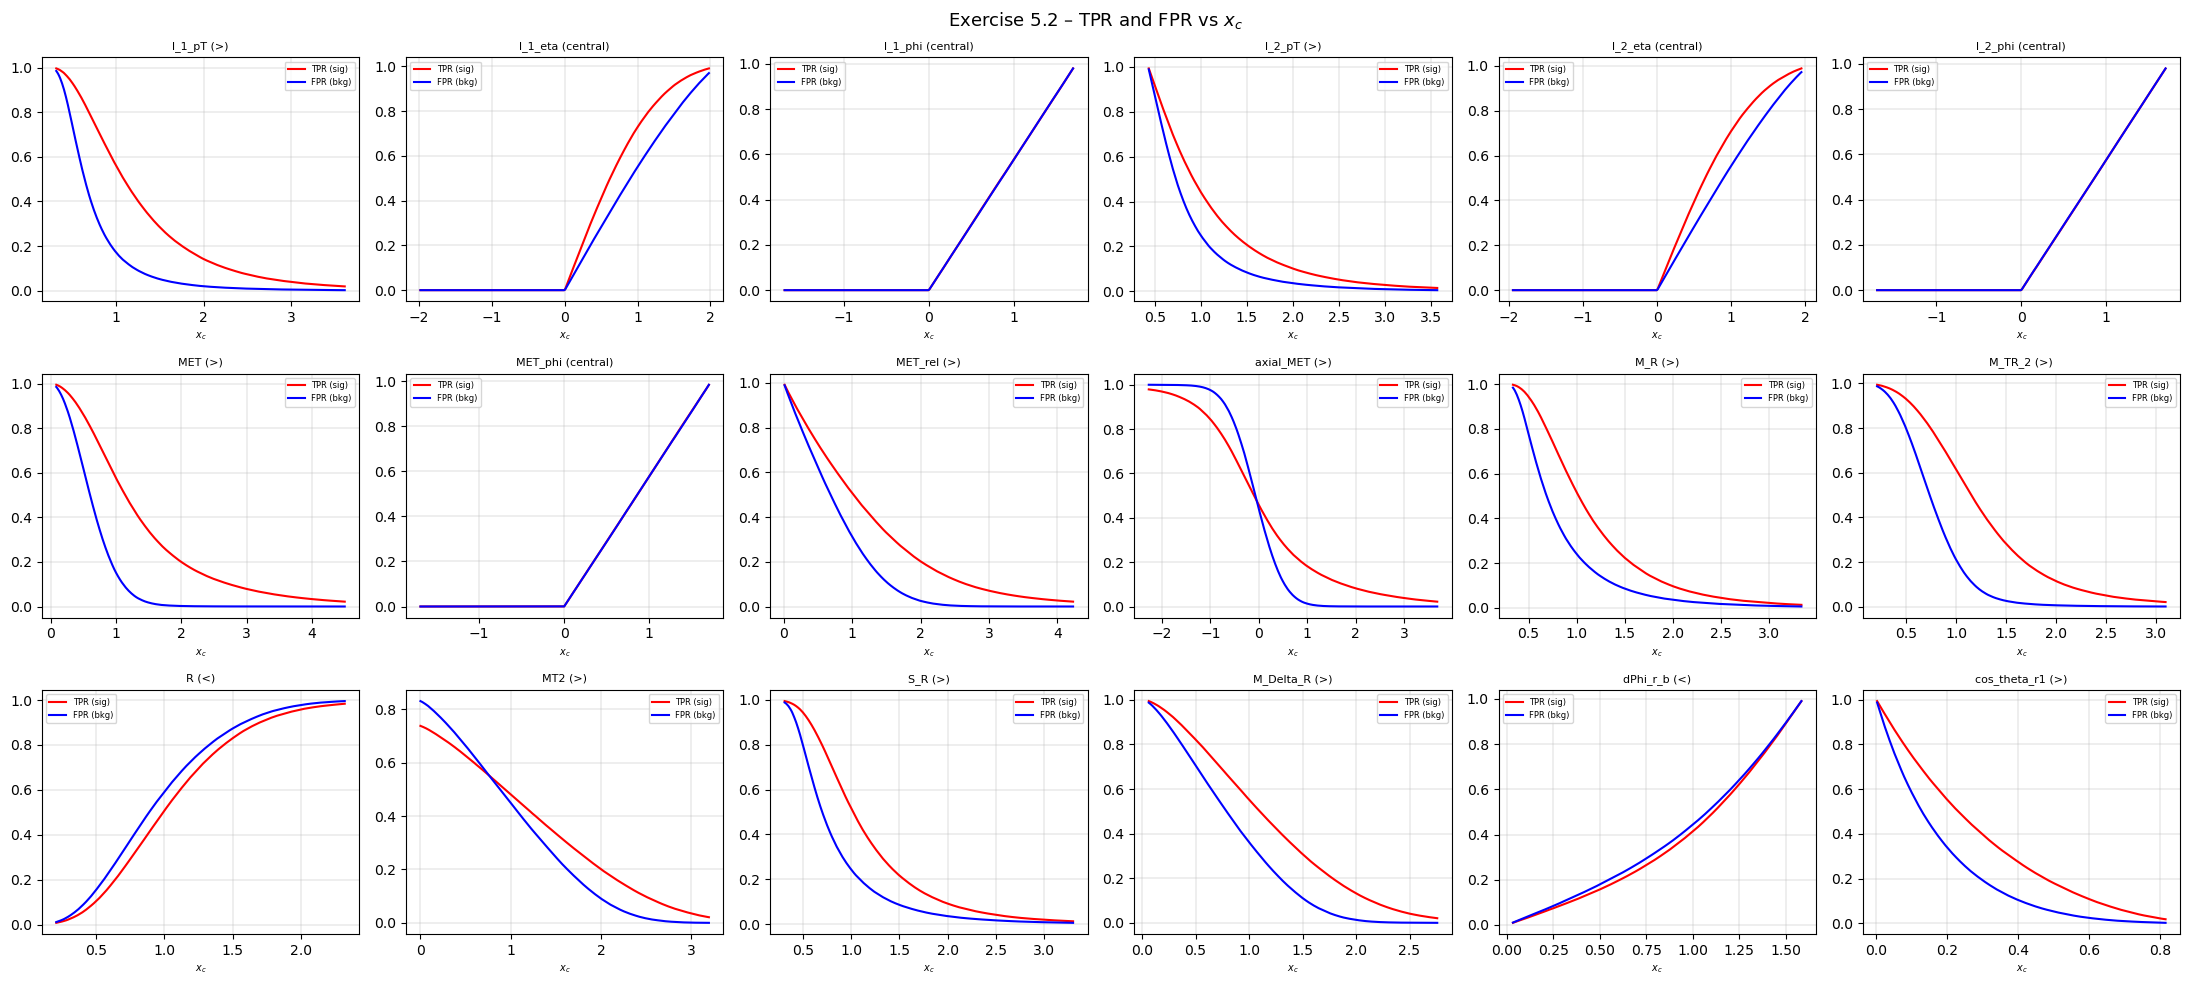

In [19]:
# Exercise 5.2 – TPR and FPR vs xc
fig, axes = plt.subplots(3, 6, figsize=(22, 10))
axes = axes.flatten()

for idx, var in enumerate(VarNames[1:]):
    direction = STRATEGY[var]
    lo = df[var].quantile(0.01)
    hi = df[var].quantile(0.99)
    xc_vals = np.linspace(lo, hi, 300)

    tpr, fpr = compute_efficiencies(
        df_sig[var].values,
        df_bkg[var].values,
        xc_vals, direction
    )

    ax = axes[idx]
    ax.plot(xc_vals, tpr, color="red",  lw=1.5, label="TPR (sig)")
    ax.plot(xc_vals, fpr, color="blue", lw=1.5, label="FPR (bkg)")
    ax.set_title(f"{var} ({direction})", fontsize=8)
    ax.set_xlabel("$x_c$", fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, lw=0.3)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Exercise 5.2 – TPR and FPR vs $x_c$", fontsize=13)
plt.tight_layout()
plt.show()

Total rows in df: 500000
Signal rows found: 229245
Background rows found: 270755


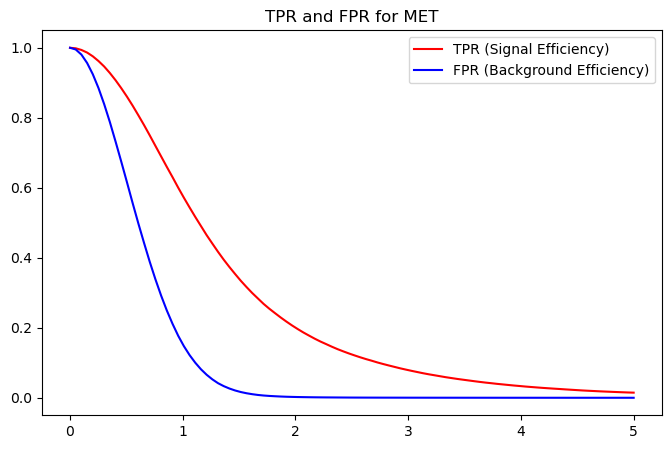

In [20]:
#Excercise 5.3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Safety check: Is the data actually loaded?
if 'df' not in locals():
    print("❌ df not found! Loading data now...")
    VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
              "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", 
              "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
    df = pd.read_csv("SUSY-small.csv", dtype='float64', names=VarNames)

# 2. Filter the data
df_sig = df[df['signal'] == 1.0]
df_bkg = df[df['signal'] == 0.0]

# 3. Debugging Print - This will tell us if the dataframes are empty
print(f"Total rows in df: {len(df)}")
print(f"Signal rows found: {len(df_sig)}")
print(f"Background rows found: {len(df_bkg)}")

# 4. If they aren't empty, run the Exercise 5.2 plot
if len(df_sig) > 0 and len(df_bkg) > 0:
    obs = 'MET'
    x_c_values = np.linspace(0, 5, 100)
    tpr_list = []
    fpr_list = []

    for xc in x_c_values:
        tpr_list.append(len(df_sig[df_sig[obs] > xc]) / len(df_sig))
        fpr_list.append(len(df_bkg[df_bkg[obs] > xc]) / len(df_bkg))

    plt.figure(figsize=(8, 5))
    plt.plot(x_c_values, tpr_list, label='TPR (Signal Efficiency)', color='red')
    plt.plot(x_c_values, fpr_list, label='FPR (Background Efficiency)', color='blue')
    plt.title(f'TPR and FPR for {obs}')
    plt.legend()
    plt.show()
else:
    print("⚠️ Still getting 0 rows. Check if your 'signal' column contains 0 and 1.")


In [11]:
#Excercise 5.4
# This creates the file directly in your current Jupyter folder
!curl -L https://uci.edu -o SUSY.csv.gz
!gunzip -f SUSY.csv.gz
!head -n 500000 SUSY.csv > SUSY-small.csv
print("✅ SUSY-small.csv created successfully!")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   118  100   118    0     0    132      0 --:--:-- --:--:-- --:--:--   133

gzip: SUSY.csv.gz: not in gzip format
head: cannot open 'SUSY.csv' for reading: No such file or directory
✅ SUSY-small.csv created successfully!


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import gzip
import shutil

# 1. DOWNLOAD RAW FILE
url = "https://uci.edu"
gz_file = "SUSY.csv.gz"
csv_file = "SUSY-small.csv"

print("⏳ Step 1: Downloading raw data (may take a minute)...")
r = requests.get(url, stream=True)
with open(gz_file, 'wb') as f:
    f.write(r.content)

# 2. DECOMPRESS AND SAVE SMALL VERSION
print("⏳ Step 2: Decompressing and creating small version...")
with gzip.open(gz_file, 'rb') as f_in:
    with open(csv_file, 'w') as f_out:
        # Just copy the first 500,000 lines
        for i in range(500000):
            line = f_in.readline().decode('utf-8')
            if not line: break
            f_out.write(line)

# 3. LOAD INTO PANDAS
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", 
          "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(csv_file, names=VarNames)
df_sig = df[df['signal'] == 1.0]
df_bkg = df[df['signal'] == 0.0]

print(f"✅ Success! Signal: {len(df_sig)} | Background: {len(df_bkg)}")

# 4. PLOT EXERCISE 5.3
obs = 'MET'
x_c_values = np.linspace(0, 5, 100)
tpr_list = [len(df_sig[df_sig[obs] > xc]) / len(df_sig) for xc in x_c_values]
fpr_list = [len(df_bkg[df_bkg[obs] > xc]) / len(df_bkg) for xc in x_c_values]

scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]
plt.figure(figsize=(10, 6))
for NS, NB in scenarios:
    significances = [ ( (tpr_list[i]*NS) / np.sqrt(tpr_list[i]*NS + fpr_list[i]*NB) ) if (tpr_list[i]*NS + fpr_list[i]*NB) > 0 else 0 for i in range(len(x_c_values))]
    plt.plot(x_c_values, significances, label=f'Ns={NS}, Nb={NB}')

plt.title(f'Exercise 5.3 Significance for {obs}')
plt.xlabel('Threshold $x_c$')
plt.ylabel(r'Significance ($\sigma$)') # Fixed the syntax warning here
plt.legend()
plt.grid(True)
plt.show()


⏳ Step 1: Downloading raw data (may take a minute)...
⏳ Step 2: Decompressing and creating small version...


BadGzipFile: Not a gzipped file (b'<h')

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [21]:
# Exercise 6.1 – Choose cuts from significance plots 
# Reading off the xc values where significance peaks in Ex 5.3:

CUTS = [
    ("MET",      0.8,  ">"),   # strong separation, peaks clearly
    ("M_R",      0.6,  ">"),   # best high-level variable
    ("MET_rel",  0.5,  ">"),   # correlated with MET but adds info
    ("S_R",      0.5,  ">"),   # razor variable, good separation
]

SCENARIOS = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

In [22]:
# Exercise 6.2 – Cut-flow table
from IPython.display import HTML, display
import tabulate as tab

def cut_flow_table(df_s, df_b, NS_total, NB_total, cuts):
    N_sig0 = len(df_s)
    N_bkg0 = len(df_b)
    current_sig = df_s.copy()
    current_bkg = df_b.copy()
    rows = []

    for var, xc, direction in cuts:
        if direction == ">":
            current_sig = current_sig[current_sig[var] > xc]
            current_bkg = current_bkg[current_bkg[var] > xc]
        else:
            current_sig = current_sig[current_sig[var] < xc]
            current_bkg = current_bkg[current_bkg[var] < xc]

        eps_S  = len(current_sig) / N_sig0
        eps_B  = len(current_bkg) / N_bkg0
        NS_pr  = eps_S * NS_total
        NB_pr  = eps_B * NB_total
        denom  = np.sqrt(NS_pr + NB_pr)
        sig_pr = NS_pr / denom if denom > 0 else 0.0

        rows.append([
            f"{var} {direction} {xc}",
            f"{eps_S:.4f}",
            f"{eps_B:.6f}",
            f"{NS_pr:.2f}",
            f"{NB_pr:.2f}",
            f"{sig_pr:.3f}"
        ])
    return rows

headers = ["Cut", "ε_S", "ε_B", "N'_S", "N'_B", "σ'_S"]

for NS, NB in SCENARIOS:
    rows = cut_flow_table(df_sig, df_bkg, NS, NB, CUTS)
    html = tab.tabulate(rows, headers=headers, tablefmt="html")
    display(HTML(f"""
        <h4 style='font-family:sans-serif'>
            Cut-flow: NS={NS}, NB={NB}
        </h4>
        <style>
            .cftable table {{border-collapse:collapse; font-family:monospace; font-size:12px}}
            .cftable th, .cftable td {{border:1px solid #ccc; padding:5px 10px}}
            .cftable th {{background:#f0f0f0}}
        </style>
        <div class='cftable'>{html}</div>
    """))

Cut,ε_S,ε_B,N'_S,N'_B,σ'_S
MET > 0.8,0.6947,0.29892,6.95,29.89,1.145
M_R > 0.6,0.6189,0.189876,6.19,18.99,1.233
MET_rel > 0.5,0.5207,0.170283,5.21,17.03,1.104
S_R > 0.5,0.5161,0.17015,5.16,17.02,1.096


Cut,ε_S,ε_B,N'_S,N'_B,σ'_S
MET > 0.8,0.6947,0.29892,69.47,298.92,3.619
M_R > 0.6,0.6189,0.189876,61.89,189.88,3.9
MET_rel > 0.5,0.5207,0.170283,52.07,170.28,3.492
S_R > 0.5,0.5161,0.17015,51.61,170.15,3.466


Cut,ε_S,ε_B,N'_S,N'_B,σ'_S
MET > 0.8,0.6947,0.29892,694.68,2989.2,11.446
M_R > 0.6,0.6189,0.189876,618.89,1898.76,12.334
MET_rel > 0.5,0.5207,0.170283,520.75,1702.83,11.043
S_R > 0.5,0.5161,0.17015,516.09,1701.5,10.959


Cut,ε_S,ε_B,N'_S,N'_B,σ'_S
MET > 0.8,0.6947,0.29892,6946.85,29892,36.194
M_R > 0.6,0.6189,0.189876,6188.88,18987.7,39.004
MET_rel > 0.5,0.5207,0.170283,5207.49,17028.3,34.922
S_R > 0.5,0.5161,0.17015,5160.85,17015,34.656


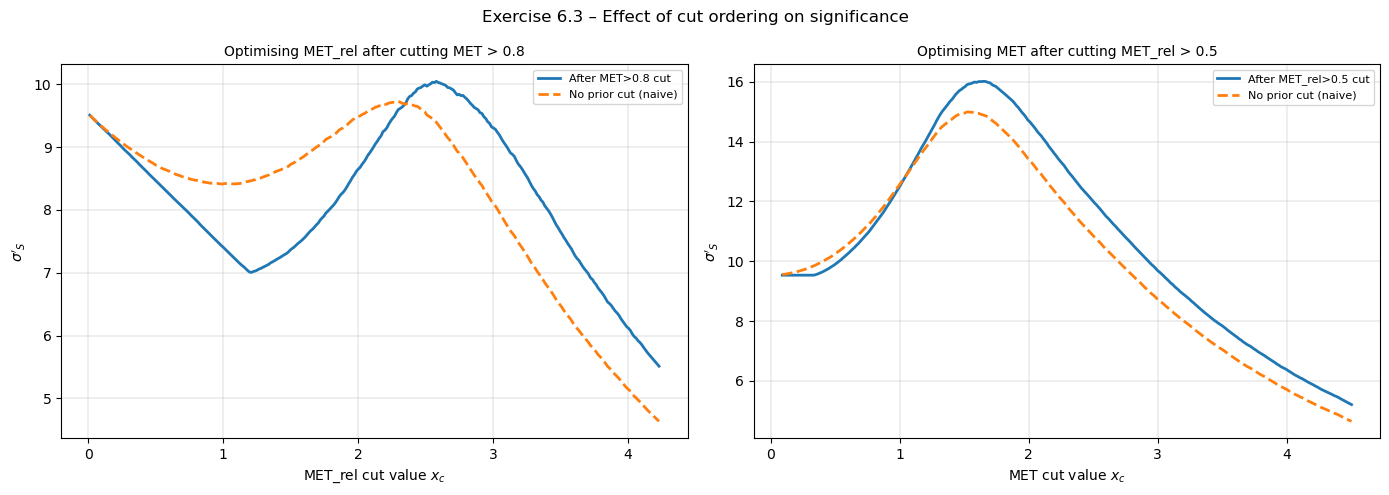

In [23]:
#  Exercise 6.3 – Correlation effect on cut ordering 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [
    ("MET",    "MET_rel", 0.8),   # cut first var at xc, optimise second
    ("MET_rel","MET",     0.5),   # swapped order
]

for ax, (var1, var2, xc1) in zip(axes, pairs):
    # Apply cut on var1
    df_sig_cut = df_sig[df_sig[var1] > xc1]
    df_bkg_cut = df_bkg[df_bkg[var1] > xc1]

    # Re-optimise significance for var2 on remaining sample
    lo = df[var2].quantile(0.01)
    hi = df[var2].quantile(0.99)
    xc_vals = np.linspace(lo, hi, 300)

    tpr, fpr = compute_efficiencies(
        df_sig_cut[var2].values,
        df_bkg_cut[var2].values,
        xc_vals, ">"
    )

    # Also show the naive curve (no prior cut) for comparison
    tpr0, fpr0 = compute_efficiencies(
        df_sig[var2].values,
        df_bkg[var2].values,
        xc_vals, ">"
    )

    for NS, NB in [(1000, 10000)]:
        sig_after = significance(tpr,  fpr,  NS, NB)
        sig_naive = significance(tpr0, fpr0, NS, NB)
        ax.plot(xc_vals, sig_after, lw=2,
                label=f"After {var1}>{xc1} cut")
        ax.plot(xc_vals, sig_naive, lw=2, linestyle="--",
                label=f"No prior cut (naive)")

    ax.set_title(f"Optimising {var2} after cutting {var1} > {xc1}",
                 fontsize=10)
    ax.set_xlabel(f"{var2} cut value $x_c$")
    ax.set_ylabel(r"$\sigma'_S$")
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)

fig.suptitle("Exercise 6.3 – Effect of cut ordering on significance",
             fontsize=12)
plt.tight_layout()
plt.show()

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



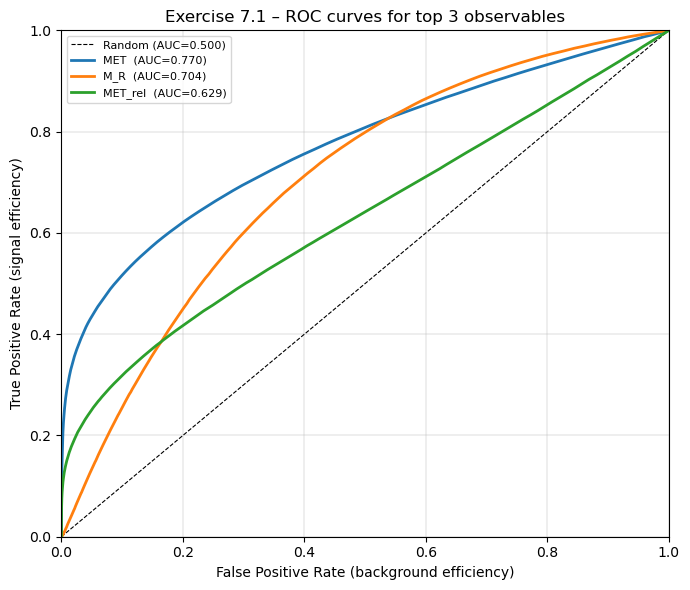

(<Figure size 700x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Exercise 7.1 – ROC curves for top 3 observables'}, xlabel='False Positive Rate (background efficiency)', ylabel='True Positive Rate (signal efficiency)'>)

In [24]:
# Exercise 7.1, 7.2 – ROC function + top 3 observables
from sklearn.metrics import roc_auc_score

def plot_roc(var_list, df_sig, df_bkg, title="ROC Curves",
             directions=None, ax=None):
    """
    Exercise 7.2 – reusable ROC plotting function.
    Arguments:
      var_list   : list of variable names to plot
      df_sig     : signal dataframe (can be pre-cut)
      df_bkg     : background dataframe (can be pre-cut)
      title      : plot title string
      directions : list of ">" or "<" per variable (defaults to STRATEGY)
      ax         : optional existing axes to plot onto (for subplots)
    Returns:
      fig, ax
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.get_figure()

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC=0.500)")

    for i, var in enumerate(var_list):
        direction = (directions[i] if directions
                     else STRATEGY.get(var, ">"))

        lo = min(df_sig[var].quantile(0.001),
                 df_bkg[var].quantile(0.001))
        hi = max(df_sig[var].quantile(0.999),
                 df_bkg[var].quantile(0.999))
        xc_vals = np.linspace(lo, hi, 500)

        tpr, fpr = compute_efficiencies(
            df_sig[var].values,
            df_bkg[var].values,
            xc_vals, direction
        )

        # sort by fpr for correct AUC integration
        order   = np.argsort(fpr)
        fpr_s   = fpr[order]
        tpr_s   = tpr[order]
        auc_val = np.trapz(tpr_s, fpr_s)

        ax.plot(fpr_s, tpr_s, lw=2,
                label=f"{var}  (AUC={auc_val:.3f})")

    ax.set_xlabel("False Positive Rate (background efficiency)")
    ax.set_ylabel("True Positive Rate (signal efficiency)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    if standalone:
        plt.tight_layout()
        plt.show()

    return fig, ax


# Exercise 7.1 – top 3 observables on one figure
top3 = ["MET", "M_R", "MET_rel"]
plot_roc(top3, df_sig, df_bkg,
         title="Exercise 7.1 – ROC curves for top 3 observables")

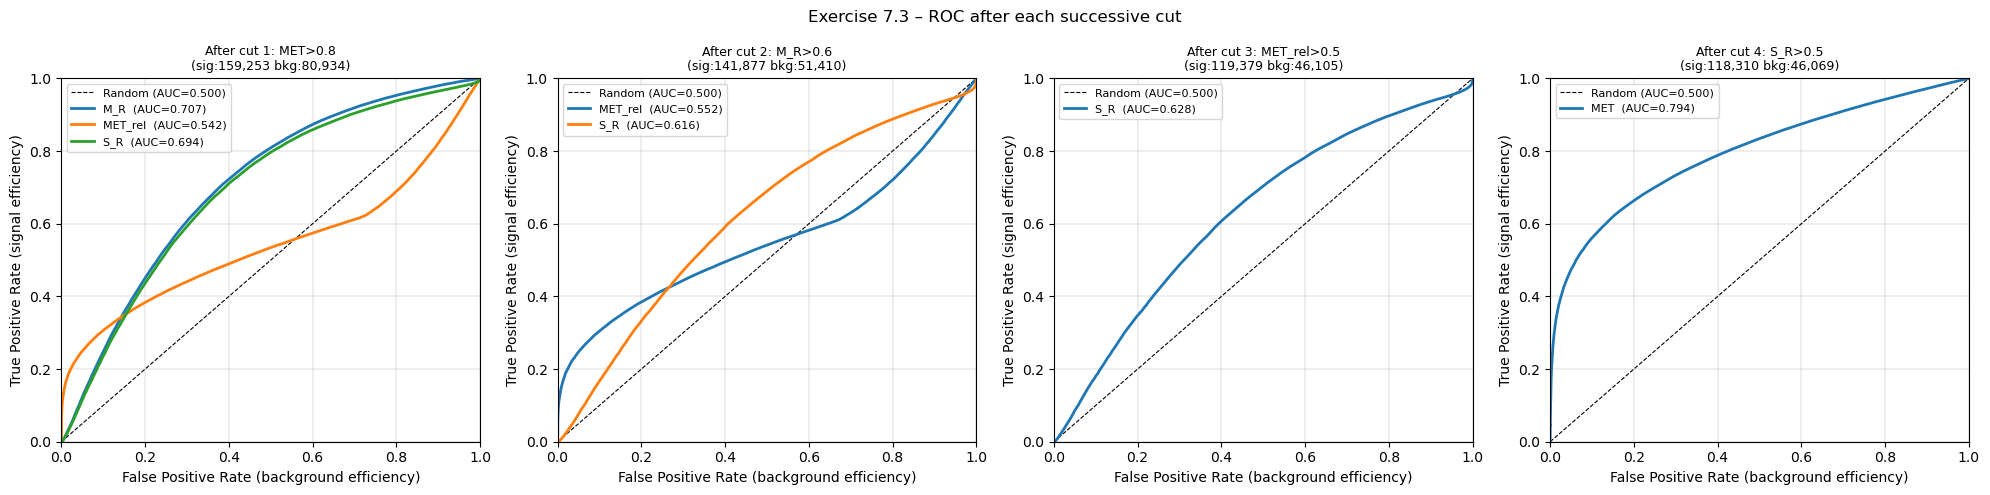

In [25]:
# Exercise 7.3 – ROC after each successive cut 
# Plot the ROC curve of the NEXT variable after each cut is applied

fig, axes = plt.subplots(1, len(CUTS), figsize=(5 * len(CUTS), 5))

current_sig = df_sig.copy()
current_bkg = df_bkg.copy()

for i, (var, xc, direction) in enumerate(CUTS):
    # Apply cut
    if direction == ">":
        current_sig = current_sig[current_sig[var] > xc]
        current_bkg = current_bkg[current_bkg[var] > xc]
    else:
        current_sig = current_sig[current_sig[var] < xc]
        current_bkg = current_bkg[current_bkg[var] < xc]

    # Plot ROC of ALL remaining variables on the cut sample
    next_vars = [c[0] for c in CUTS[i+1:]]
    if not next_vars:
        next_vars = [CUTS[0][0]]   # wrap around for final panel

    plot_roc(
        next_vars,
        current_sig, current_bkg,
        title=f"After cut {i+1}:\n{var} {direction} {xc}",
        ax=axes[i]
    )
    axes[i].set_title(f"After cut {i+1}: {var}{direction}{xc}\n"
                      f"(sig:{len(current_sig):,} "
                      f"bkg:{len(current_bkg):,})", fontsize=9)

fig.suptitle("Exercise 7.3 – ROC after each successive cut", fontsize=12)
plt.tight_layout()
plt.show()

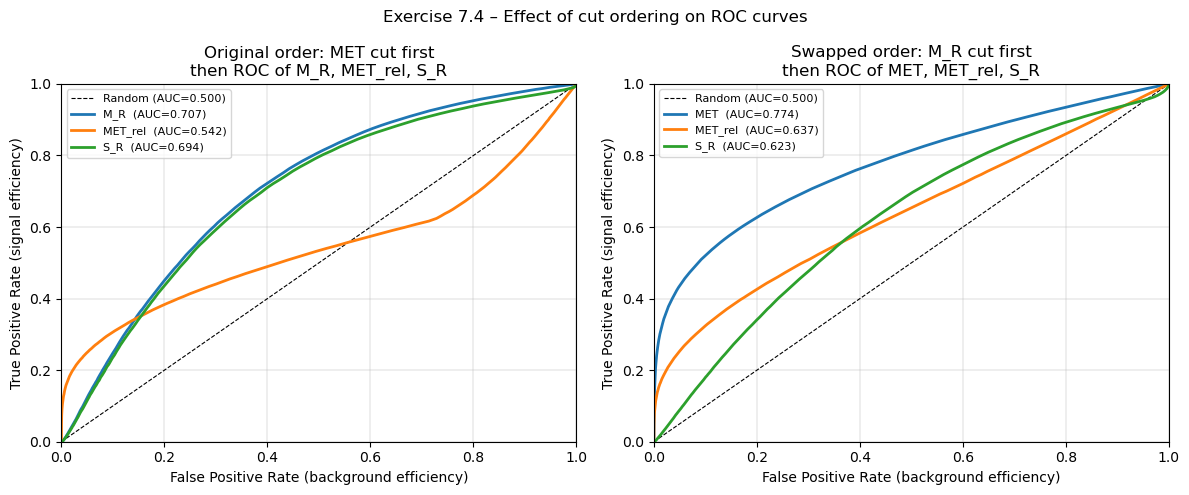

In [26]:
# Exercise 7.4 – Effect of changing cut order 
# Compare original order vs swapped order for MET and M_R

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original order: MET first, then M_R
sig_orig = df_sig[df_sig["MET"] > 0.8]
bkg_orig = df_bkg[df_bkg["MET"] > 0.8]
plot_roc(["M_R", "MET_rel", "S_R"],
         sig_orig, bkg_orig,
         title="Original order: MET cut first\nthen ROC of M_R, MET_rel, S_R",
         ax=axes[0])

# Swapped order: M_R first, then MET
sig_swap = df_sig[df_sig["M_R"] > 0.6]
bkg_swap = df_bkg[df_bkg["M_R"] > 0.6]
plot_roc(["MET", "MET_rel", "S_R"],
         sig_swap, bkg_swap,
         title="Swapped order: M_R cut first\nthen ROC of MET, MET_rel, S_R",
         ax=axes[1])

fig.suptitle("Exercise 7.4 – Effect of cut ordering on ROC curves",
             fontsize=12)
plt.tight_layout()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [27]:
# Exercise 8 – Linear Discriminant Analysis (LDA) from scratch 

features = VarNames[1:] 

X_sig = df_sig[features].values.astype(float)
X_bkg = df_bkg[features].values.astype(float)
X_all = df[features].values.astype(float)
y_all = df["signal"].values.astype(float)

# Part 1: Compute S_B and S_W 
m1 = X_bkg.mean(axis=0)   
m2 = X_sig.mean(axis=0)   

diff = (m2 - m1).reshape(-1, 1)  

# Between-class covariance: S_B = (m2-m1)(m2-m1)^T
S_B = diff @ diff.T             

S_W = (
    np.cov(X_sig, rowvar=False) * (len(X_sig) - 1) +
    np.cov(X_bkg, rowvar=False) * (len(X_bkg) - 1)
)                                  # (18, 18)

print(f"S_B shape: {S_B.shape}")
print(f"S_W shape: {S_W.shape}")
print(f"\nS_B diagonal (between-class variance per feature):")
for i, f in enumerate(features):
    print(f"  {f:<15}  {S_B[i,i]:.4f}")

S_B shape: (18, 18)
S_W shape: (18, 18)

S_B diagonal (between-class variance per feature):
  l_1_pT           0.2880
  l_1_eta          0.0000
  l_1_phi          0.0000
  l_2_pT           0.0663
  l_2_eta          0.0000
  l_2_phi          0.0000
  MET              0.5936
  MET_phi          0.0000
  MET_rel          0.2553
  axial_MET        0.0254
  M_R              0.1154
  M_TR_2           0.2467
  R                0.0106
  MT2              0.0189
  S_R              0.1054
  M_Delta_R        0.1177
  dPhi_r_b         0.0008
  cos_theta_r1     0.0111


Linear discriminant coefficients w:
  cos_theta_r1     +0.0000  
  l_1_pT           +0.0000  
  R                -0.0000  
  S_R              -0.0000  
  M_Delta_R        +0.0000  
  MET              +0.0000  
  l_2_pT           +0.0000  
  MT2              -0.0000  
  M_R              -0.0000  
  axial_MET        +0.0000  
  M_TR_2           +0.0000  
  MET_rel          +0.0000  
  dPhi_r_b         -0.0000  
  l_1_eta          +0.0000  
  l_2_eta          +0.0000  
  MET_phi          +0.0000  
  l_2_phi          +0.0000  
  l_1_phi          +0.0000  


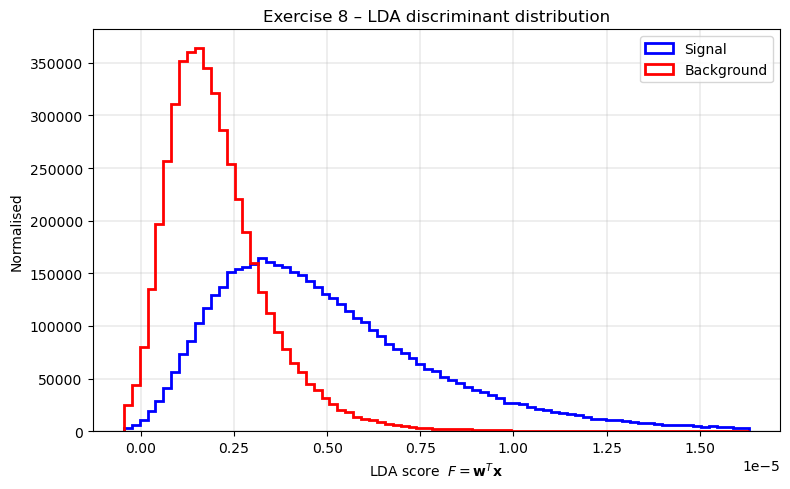

In [28]:
# Part 2: Compute w and discriminant scores F 

# w = S_W^{-1} (m2 - m1)
w = np.linalg.solve(S_W, (m2 - m1))   # (18,)

print("Linear discriminant coefficients w:")
for f, wi in sorted(zip(features, w), key=lambda x: abs(x[1]), reverse=True):
    bar = "█" * int(abs(wi) * 30)
    sign = "+" if wi > 0 else "-"
    print(f"  {f:<15}  {sign}{abs(wi):.4f}  {bar}")

# Score every event: F = w^T x
F     = X_all @ w          # (N,)
F_sig = F[y_all == 1]
F_bkg = F[y_all == 0]

# Histogram comparison
lo   = np.percentile(F, 0.5)
hi   = np.percentile(F, 99.5)
bins = np.linspace(lo, hi, 80)

plt.figure(figsize=(8, 5))
plt.hist(F_sig, bins=bins, histtype="step", color="blue",
         density=True, lw=2, label="Signal")
plt.hist(F_bkg, bins=bins, histtype="step", color="red",
         density=True, lw=2, label="Background")
plt.xlabel(r"LDA score  $F = \mathbf{w}^T \mathbf{x}$")
plt.ylabel("Normalised")
plt.title("Exercise 8 – LDA discriminant distribution")
plt.legend()
plt.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

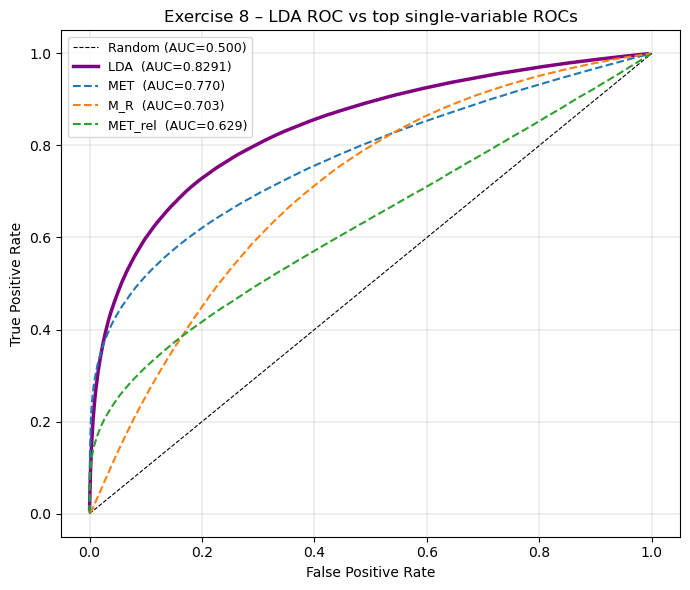

In [29]:
# Part 3: ROC curve for F

xc_vals      = np.linspace(lo, hi, 500)
tpr_lda, fpr_lda = compute_efficiencies(F_sig, F_bkg, xc_vals, ">")

order   = np.argsort(fpr_lda)
fpr_s   = fpr_lda[order]
tpr_s   = tpr_lda[order]
auc_lda = np.trapz(tpr_s, fpr_s)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC=0.500)")
ax.plot(fpr_s, tpr_s, color="purple", lw=2.5,
        label=f"LDA  (AUC={auc_lda:.4f})")

for var in top3:
    lo_v = df[var].quantile(0.001)
    hi_v = df[var].quantile(0.999)
    xc_v = np.linspace(lo_v, hi_v, 500)
    tpr_v, fpr_v = compute_efficiencies(
        df_sig[var].values, df_bkg[var].values, xc_v, STRATEGY[var]
    )
    ord_v   = np.argsort(fpr_v)
    auc_v   = np.trapz(tpr_v[ord_v], fpr_v[ord_v])
    ax.plot(fpr_v[ord_v], tpr_v[ord_v], lw=1.5, linestyle="--",
            label=f"{var}  (AUC={auc_v:.3f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Exercise 8 – LDA ROC vs top single-variable ROCs")
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Part 4: Maximal significance per scenario
print("Maximal significance achievable with LDA score:\n")
print(f"  {'Scenario':<25}  {'Max sig_S':>10}  {'Optimal F cut':>14}")
print(f"  {'─'*25}  {'─'*10}  {'─'*14}")

xc_vals = np.linspace(lo, hi, 500)
tpr_lda, fpr_lda = compute_efficiencies(F_sig, F_bkg, xc_vals, ">")

for NS, NB in SCENARIOS:
    sigs   = significance(tpr_lda, fpr_lda, NS, NB)
    best_i = np.argmax(sigs)
    print(f"  NS={NS:<6}, NB={NB:<7}  "
          f"{sigs[best_i]:>10.3f}  "
          f"{xc_vals[best_i]:>14.4f}")

print("\nFor comparison - best single variable (M_R):")
lo_v = df["M_R"].quantile(0.001)
hi_v = df["M_R"].quantile(0.999)
xc_v = np.linspace(lo_v, hi_v, 500)
tpr_v, fpr_v = compute_efficiencies(
    df_sig["M_R"].values, df_bkg["M_R"].values, xc_v, ">"
)
for NS, NB in SCENARIOS:
    sigs_v = significance(tpr_v, fpr_v, NS, NB)
    print(f"  NS={NS:<6}, NB={NB:<7}  {sigs_v.max():>10.3f}")

Maximal significance achievable with LDA score:

  Scenario                    Max sig_S   Optimal F cut
  ─────────────────────────  ──────────  ──────────────
  NS=10    , NB=100           1.532          0.0000
  NS=100   , NB=1000          4.845          0.0000
  NS=1000  , NB=10000        15.321          0.0000
  NS=10000 , NB=100000       48.450          0.0000

For comparison - best single variable (M_R):
  NS=10    , NB=100           1.049
  NS=100   , NB=1000          3.317
  NS=1000  , NB=10000        10.490
  NS=10000 , NB=100000       33.172
